<div style="position: relative; background: linear-gradient(135deg, #24398A 0%, #1a2a66 100%); border-radius: 20px 20px 0px 0px; padding: 30px; box-shadow: 0 8px 16px rgba(36, 57, 138, 0.3);">
  
  <!-- Logo UNISON - Derecha -->
  <div style="position: absolute; top: 20px; right: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/logo_unison.jpg" alt="UNISON" style="height: 160px;">
  </div>
  
  <!-- Imagen Izquierda -->
  <div style="position: absolute; top: 20px; left: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/genetic_banner.jpg" alt="Curso" style="height: 160px;">
  </div>
   
  <!-- Título centrado -->
  <div style="color: white; max-width: 60%; margin: 0 auto; text-align: center;">
    <h1 style="color: #EBA93B; margin: 0; font-size: 28px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
      Metaheurísticas para Ciencia de Datos: <br>Teoría y Práctica
    </h1><br>
    <h3 style="margin: 15px 0 5px 0; font-size: 16px; opacity: 0.95;">Maestría en Ciencia de Datos</br></br>
    Ramón Soto C. / ramon.soto@unison.mx</h3>
  </div>
</div>

<div style="background: white; border: 3px solid #EBA93B; border-radius: 0px 0px 20px 20px; padding: 25px;">
  <div style="display: flex; align-items: center; margin-bottom: 15px;">
    <div style="background: #24398A; color: white; font-size: 24px; font-weight: bold; padding: 10px 20px; border-radius: 8px; margin-right: 20px;">03</div>
    <div>
      <h2 style="color: #24398A; margin: 0;">Computación Evolutiva: Algoritmos basados en la evolución</h2>
      <p style="color: #666; margin: 5px 0 0 0; font-style: italic;">De 3.800 millones de años de evolución a metaheurísticas poblacionales</p>
    </div>
  </div>
  
<div style="background: #f8f9fa; padding: 15px; border-radius: 5px; border-left: 4px solid #24398A;">
    <h4 style="color: #24398A; margin-top: 0;"><strong>Presentación general</strong></h4>
    <p style="line-height: 1.7; color: #333;">
    La evolución biológica es el algoritmo de optimización más exitoso de la naturaleza: durante 3.800 millones de años ha resuelto problemas de diseño, adaptación y supervivencia en ambientes hostiles, inciertos y cambiantes. La pregunta natural desde ML es: ¿Podemos abstraer sus principios fundamentales—variación, selección, herencia—y convertirlos en métodos computacionales? 
    </p>
    <p style="line-height: 1.7; color: #333;">
    Esta lección explora los <strong>algoritmos evolutivos</strong>, una familia de metaheurísticas donde poblaciones de soluciones candidatas compiten, se recombinan y mutan para adaptarse progresivamente a un paisaje de <em>fitness</em>. Desde los algoritmos genéticos clásicos hasta las estrategias evolutivas modernas, veremos cómo la metáfora de la selección natural se traduce en mecanismos computacionales robustos capaces de navegar espacios de búsqueda rugosos, discontinuos y multimodales—exactamente los problemas que encontramos en sistemas complejos.
    </p>
    <p style="line-height: 1.7; color: #333;">
    Analizaremos también los desafíos inherentes: convergencia prematura hacia óptimos locales, crecimiento descontrolado de la complejidad (<em>bloat</em>), balance entre exploración y explotación. Y aprenderemos estrategias para superarlos, preparando el camino para aplicaciones en calibración de modelos, selección de características, y optimización de hiperparámetros en ciencia de datos.
    </p>
  </div>
</div>


<div style="padding: 15px 20px; background-color: #f8f9fa; margin: 20px 0;">
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0 0 15px 0;">
        En la lección anterior vimos que los sistemas complejos—desde el atractor de Lorenz hasta mercados financieros—violan sistemáticamente los supuestos de los métodos clásicos. No son lineales, no son convexos, no son estacionarios. En esos paisajes rugosos y multimodales, <strong>necesitamos métodos que no asuman estructura favorable</strong>.
    </p>
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0;">
        Los <strong>algoritmos evolutivos</strong> son precisamente eso: métodos de búsqueda poblacional inspirados en la selección natural, que exploran el espacio de soluciones de manera distribuida y paralela. Implementan procesos de <em>variación</em> (mutación, recombinación), <em>selección</em> (supervivencia diferencial), y <em>herencia</em> (transmisión de características exitosas), permitiendo que poblaciones de candidatos evolucionen hacia regiones de alta aptitud sin quedarse atrapados en óptimos locales. Esta lección explora cómo convertir la metáfora evolutiva en algoritmos rigurosos y aplicables.
    </p>
</div>


In [1]:
# CONFIGURACIÓN INICIAL
# =====================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from scipy import stats
from itertools import combinations
import math
from mpl_toolkits.mplot3d import Axes3D

# Configuración estética
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12


# Reproducibilidad
np.random.seed(42)

print("Librerías cargadas exitosamente.\n")

Librerías cargadas exitosamente.



## 1. La evolución como algoritmo

En las lecciones anteriores discutimos que gran parte de la ciencia avanza gracias a **metáforas**: imágenes conceptuales que permiten pensar lo que aún no puede formularse con precisión matemática. 

La evolución biológica no es una excepción. Es un proceso natural que, visto con distancia, se comporta como un **algoritmo distribuido**, lento pero obstinadamente eficaz, que explora un espacio inmenso de posibilidades.

En **Computación Evolutiva (CE)**, igual que en cualquier otro método metaheurístico, no tratamos de "copiar" ese proceso, sino de extraer su **estructura funcional**:

```
DIVERSIDAD → SELECCIÓN → VARIACIÓN → SUPERVIVENCIA DIFERENCIAL
```

Desde esta perspectiva, los algoritmos evolutivos son **metáforas computacionales de la adaptación**, un puente directo entre naturaleza y diseño algorítmico. Esta estructura —muy simple en apariencia— permite resolver problemas donde los métodos convencionales fallan:

- Optimización no convexa
- Espacios ruidosos y discontinuos
- Problemas combinatorios (NP-duros)
- Paisajes multimodales

Esta estructura puede describirse en términos de operadores de búsqueda y presión selectiva, lo que permite compararla con métodos deterministas clásicos.

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Reflexión epistemológica:</strong> Si aceptamos que las redes neuronales son una metáfora válida (y simplificada) del cerebro, ¿por qué no aceptar que los algoritmos evolutivos son una metáfora válida (y simplificada) de la evolución?
</div>

---

## 2. Computación evolutiva

La **Computación evolutiva (CE)** es una familia de métodos inspirados en los mecanismos biológicos de adaptación. En el diagrama se muestran los principales enfoques en computación evolutiva:

<br>

<p align="center">
  <img src="images/genetic_tree.png" width="500">
</p>

<br>

No se trata aquí de una imitación literal de la naturaleza, sino una **abstracción del proceso evolutivo**:

<center>
<h3>GENERAR VARIACIÓN → EVALUAR CALIDAD → RETENER LO QUE FUNCIONA → REPETIR</h3>
</center>

<br>


### Los Cuatro Pilares Fundamentales

Todas las variantes de CE comparten estos elementos esenciales:

| Elemento | Descripción | Analogía Biológica |
|----------|-------------|-------------------|
| **1. Población** | Conjunto de soluciones candidatas | Población de organismos |
| **2. Aptitud** | Medida de calidad de cada solución | Aptitud para sobrevivir **y reproducirse** |
| **3. Variación** | Operadores que generan diversidad | Mutación y recombinación genética |
| **4. Selección** | Mecanismo para decidir (**arbitrariamente**) qué soluciones sobreviven | Selección natural |

<br>

<p align="center">
  <img src="images/human_evolution.png" width="600">
</p>


### El esquema minimalista que funciona

El esquema general de un algoritmo evolutivo es notablemente simple, casi minimalista:

```python
INICIALIZAR población aleatoria
EVALUAR fitness de cada individuo

REPETIR por G generaciones:
    EVALUAR fitness de individuos
    SELECCIONAR padres (basado en fitness)
    CREAR nueva generación
        APLICAR operadores de variación (cruza, mutación)
        APLICAR reemplazo (generacional, elitista, etc.)

DEVOLVER mejor solución encontrada
```

Lo sorprendente es que este esquema funciona para una amplia gama de problemas:

| Tipo de Problema | Ejemplo | Por qué funciona |
|------------------|---------|------------------|
| **Combinatorio** | TSP, scheduling | Explora combinatoriamente sin enumerar todo |
| **Multimodal** | Optimización con múltiples óptimos | Mantiene diversidad poblacional |
| **No diferenciable** | Funciones con discontinuidades | No requiere gradientes (el espacio de soluciones es granular) |
| **Ruidoso** | Sistemas estocásticos | Promedia sobre múltiples evaluaciones |
| **Alta dimensión** | Feature selection (1000+ features) | Búsqueda paralela inteligente |

La clave del éxito de este enfoque es su **carácter poblacional**.

----

## 3. Algoritmo Genético Simple (AGS)

El **Algoritmo Genético Simple** es el punto de entrada más directo a la computación evolutiva: un esquema mínimo pero funcional que implementa los cuatro pilares con las decisiones de diseño más simples posibles. Es la variante más influyente históricamente y el punto de partida pedagógico típico, aunque en la práctica moderna ha sido superado por variantes más sofisticadas. 

Sin embargo, antes de extenderlo hacia formas más expresivas, conviene entenderlo en su forma más burda, con sus simplificaciones y limitaciones explícitas.

Los elementos que definen el AGS son:

- **Representación**: la codificación de la solución (en el AGS, coincide con la solución misma)
- **Aptitud**: medida escalar de la calidad de una solución candidata respecto al objetivo del problema
- **Selección**: asignación probabilística de mayor oportunidad reproductiva a soluciones de mayor aptitud
- **Recombinación**: combinación de la representación de dos soluciones parentales para generar descendencia
- **Mutación**: perturbación aleatoria de las soluciones candidatas para introducir variación
- **Reemplazo**: sustitución de la generación anterior por la nueva población de descendientes

En el AGS trabajamos con el lado derecho de estas relaciones: las definiciones operativas. Pero conviene entender desde un inicio cómo se articulan estos conceptos desde una perspectiva biológica y en qué medida las versiones computacionales los simplifican o distorsionan.

### Genotipo: La representación interna

En el caso biológico, el genotipo es la **configuración específica de secuencias de ADN** —genes, variantes alélicas y elementos regulatorios— que parametriza y regula los procesos de desarrollo de un organismo. Desde un punto de vista computacional, el genotipo es la codificación interna de la solución que el algoritmo manipula. Dependiendo del problema, puede ser una cadena binaria, un vector de números reales o, una estructura arbórea que representa un programa de computadora.

Esto implica que:

- La **representación induce el espacio de búsqueda**  
- Cambiar la codificación cambia la geometría del problema  
- Dos genotipos cercanos no necesariamente producen fenotipos cercanos

### Fenotipo: La solución expresada

Es la realización observable de un organismo: sus rasgos morfológicos, fisiológicos, conductuales y funcionales en un momento dado. No es una copia directa del genotipo, sino el resultado de un proceso de desarrollo en el que interactúan la información genética, la regulación génica, el ambiente y la historia del organismo. 

Desde el punto de vista computacional, el fenotipo es la solución interpretada que interactúa con el problema.

En el caso del AGS, el genotipo y el fenotipo coinciden: el fenotipo es el número real que optimiza nuestro problema y el genotipo la representación computacional de ese número. En nuestro caso, esta sobresimplificación nos permite concentrarnos en la lógica evolutiva antes de introducir la riqueza que surge cuando utilizamos el genotipo como una especie de representación del paisaje de búsqueda y el fenotipo como la solución.


### Aptitud (*Fitness*): La función de evaluación
En biología, la aptitud es una medida de su éxito reproductivo relativo en un ambiente específico. No es una propiedad intrínseca aislada del organismo, sino que es contextual y comparativa. 

En computación evolutiva, la aptitud es la función que evalúa el desempeño del fenotipo frente al problema. No está relacionado a “qué es” la solución, cuál es su fenotipo o su genotipo, sino “qué tan bien funciona” en el contexto del problema en condiciones específicas.

En términos del ejemplo de bisección para obtener la raíz de $f(x) = -(x-2)^2 + 10$, es decir, obtener la $x$ que evalúa a cero la funciónn, maximizar la función de *aptitud* equivale a minimizar el valor absoluto del residual.


### Selección: El filtro adaptativo
En biología, la selección natural es un proceso diferencial de supervivencia y reproducción. No elige explícitamente “al mejor”, sino que sesga probabilísticamente la contribución genética a la siguiente generación. La selección natural es impulsada y dirigida por la presión selectiva, que actúa como el "tamiz" ambiental que determina qué individuos tiene mayor probabilidad de sobrevivir y reproducirse. Esta presión se define como factores ambientales (clima, depredadores, recursos) que reducen el éxito reproductivo, forzando a las poblaciones a adaptarse o extinguirse.

En computación evolutiva, la selección es el mecanismo que asigna mayor probabilidad de reproducción a individuos con mayor *fitness*, jugando el papel de *presión selectiva*. La selección determina la foma en que se explora el paisaje de soluciones:

- Presión alta → explotación rápida
- Presión baja → exploración amplia


### Recombinación (Cruza): La mezcla de información
En biología, la recombinación genética es el proceso biológico de intercambio de segmentos de ADN entre moléculas o cromosomas, generando nuevas combinaciones de genes en los descendientes. En la cruza, este proceso mezcla material hereditario de dos progenitores, generando nuevas combinaciones de alelos.

<p align="center">
  <img src="images/recombinacion.png" width="500">
</p>

En computación evolutiva, la recombinación combina genotipos parentales para producir descendencia.


### Mutación: La fuente primaria de variación
En biología, la mutación es una alteración espontánea o inducida en la secuencia del ADN: una sustitución de bases (un nucleótido es reemplazado por otro), una deleción (se elimina uno o más nucleótidos de la secuencia de ADN), una inversión (un segmento de ADN se rompe, se invierte 180 grados y se vuelve a insertar en el mismo lugar). La mayoría de estas transformaciones son neutras o mortíferas; pero ocasionalmente, una mutación introduce una ventaja adaptativa. 

Algo que es importante destacar es que no es necesario que la mutación sea *inteligente*, sino que es aleatoria con respecto al problema: la naturaleza no dirige las mutaciones hacia donde hacen falta, no le importa el destino del cambio; **la naturaleza no tiene un objetivo**, pero a nuestros ojos "funciona".

En computación evolutiva, la mutación introduce variación aleatoria en el genotipo de un individuo, **independientemente de su aptitud**. En el AGS, esto se implementa como ruido gaussiano.


### Reemplazo: La lógica generacional
En biología, el reemplazo generacional es simplemente el hecho de que los organismos mueren y son sustituidos por su descendencia. No todos los individuos de la generación parental sobreviven para competir con sus hijos: hay recambio poblacional. El solapamiento entre generaciones varía enormemente entre especies —desde organismos estacionales hasta primates de vida larga— y esa diferencia tiene consecuencias evolutivas reales.

En computación evolutiva, el esquema de reemplazo determina cómo la población de hijos sustituye a la de padres. El AGS usa reemplazo *generacional completo*: la generación $t+1$ reemplaza íntegramente a la generación $t$. Es la política más simple, pero no la única ni necesariamente la mejor. Esquemas más sofisticados —como el reemplazo de estado estacionario o el elitismo— permiten preservar soluciones destacadas y modulan la velocidad de pérdida de diversidad. Más adelante veremos que esta decisión puede tener consecuencias directas sobre la convergencia prematura.

---

## 4. Bisección como caso límite de búsqueda evolutiva determinista

Los algoritmos evolutivos introducen estocasticidad, poblaciones grandes y operadores de variación complejos. Sin embargo, la lógica fundamental —generar candidatos, evaluar su calidad y retener los más prometedores— ya está presente en métodos numéricos clásicos.

El **método de bisección** puede interpretarse como un **caso límite** de esta lógica en un paisaje ideal:

- Unidimensional  
- Continuo  
- Sin ruido  
- Con información perfecta sobre la factibilidad (cambio de signo)  

En ese contexto, la búsqueda no requiere diversidad poblacional ni mutación; basta con una recombinación determinista y una selección perfecta.

### Descripción en términos evolutivos

Podemos describir bisección como un algoritmo evolutivo degenerado:

- **Población mínima:** dos individuos `{a, b}` que delimitan el espacio de búsqueda  
- **Operador de variación:** recombinación lineal determinista  
$c = \frac{a + b}{2}$
- **Función de evaluación:** factibilidad binaria basada en el cambio de signo  
- **Selección:** elitista y determinista (presión selectiva infinita)  
- **Mutación:** inexistente  

Esto equivale a fijar los parámetros evolutivos en sus extremos:

- Tamaño de población → 2  
- Probabilidad de recombinación → 1  
- Probabilidad de mutación → 0  
- Ruido en el fitness → 0  

Bajo estas condiciones ideales, la convergencia está garantizada y el espacio de búsqueda se reduce por un factor de 2 en cada iteración.


### Bisección: un ejemplo simple de algoritmo computacional evolutivo

Analicemos el uso de bisección para encontrar la raíz de una parábola:

$$f(x) = -(x-2)^2 + 10$$

La siguiente visualización muestra cómo cada iteración realiza:

1. **Recombinación determinista** → cálculo del punto medio  
2. **Evaluación** → signo de la función  
3. **Selección elitista** → redefinición (reduccióon) del intervalo  

Un proceso de búsqueda perfectamente organizado, porque el paisaje es perfecto.


Iteración |   a    |   b    |   c    | Error_x ≤ (b-a)/2 | Residual |f(c)|
----------┼--------┼--------┼--------┼-------------------┼-----------------
   1      | 1.0000 | 6.0000 | 3.5000 |     2.500000      |     7.750000
   2      | 3.5000 | 6.0000 | 4.7500 |     1.250000      |     2.437500
   3      | 4.7500 | 6.0000 | 5.3750 |     0.625000      |     1.390625
   4      | 4.7500 | 5.3750 | 5.0625 |     0.312500      |     0.621094
   5      | 5.0625 | 5.3750 | 5.2188 |     0.156250      |     0.360352
   6      | 5.0625 | 5.2188 | 5.1406 |     0.078125      |     0.136475
   7      | 5.1406 | 5.2188 | 5.1797 |     0.039062      |     0.110413

Raíz aproximada después de 7 iteraciones: x = 5.160156
Cota superior del error en x: 0.019531
Residual de fitness |f(x)|: 0.013412



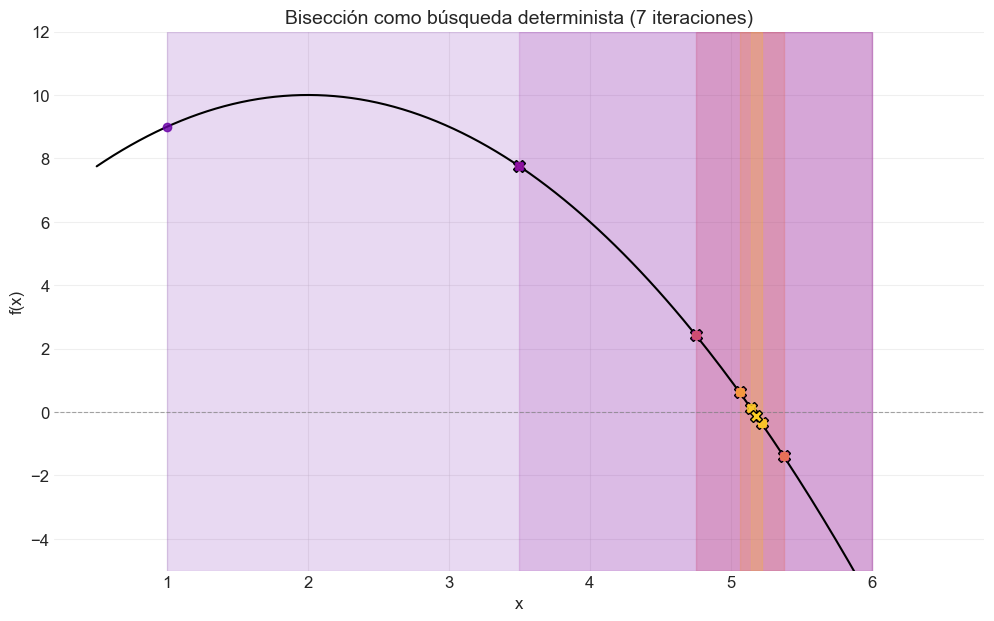

In [2]:
def f(x):
    """Función objetivo: f(x) = -(x-2)**2 + 10"""
    return -(x-2)**2 + 10


def bisection_plot(a_start, b_start, iterations=4):
    """Realiza N iteraciones de Bisección y visualiza recombinación y selección."""
    a, b = a_start, b_start
    
    if f(a) * f(b) >= 0:
        print("Error: f(a) y f(b) deben tener signos opuestos.")
        return
        
    x_vals = np.linspace(a_start - 0.5, b_start + 0.5, 200)
    y_vals = f(x_vals)
    
    plt.figure(figsize=(12, 7))
    plt.plot(x_vals, y_vals, 'k-', linewidth=1.5, label='f(x) = -(x-2)^2 + 10')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.title(f'Bisección como búsqueda determinista ({iterations} iteraciones)', fontsize=14)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, iterations))
    
    print(f"Iteración |   a    |   b    |   c    | Error_x ≤ (b-a)/2 | Residual |f(c)|")
    print("----------┼--------┼--------┼--------┼-------------------┼-----------------")
    
    for i in range(iterations):
        c = (a + b) / 2
        fc = f(c)
        error_x = (b - a) / 2
        residual = abs(fc)
        
        # Visualización de la "población" {a, b}
        plt.plot([a, b], [f(a), f(b)], 'o', color=colors[i], markersize=6, alpha=0.8)
        
        # Punto medio = recombinación determinista
        plt.plot(c, fc, 'X', color=colors[i], markersize=8, markeredgecolor='black')
        
        # Intervalo sobreviviente = selección elitista
        plt.axvspan(a, b, color=colors[i], alpha=0.15)
        
        print(f"{i+1:4}      | {a:.4f} | {b:.4f} | {c:.4f} |     {error_x:.6f}      |     {residual:.6f}")
        
        # Selección determinista
        if f(a) * fc < 0:
            b = c
        else:
            a = c
            
    final_c = (a + b) / 2
    final_error = (b - a) / 2
    final_residual = abs(f(final_c))

    print(f"\nRaíz aproximada después de {iterations} iteraciones: x = {final_c:.6f}")
    print(f"Cota superior del error en x: {final_error:.6f}")
    print(f"Residual de fitness |f(x)|: {final_residual:.6f}\n")

    plt.ylim(-5, 12)
    plt.grid(True, alpha=0.3)
    plt.show()
    

# Ejecución
bisection_plot(a_start=1.0, b_start=6.0, iterations=7)


### Notas:

#### Error en el espacio de soluciones (genotipo)
En el método de bisección, el error en la variable $x$ está directamente acotado por el tamaño del intervale, de la siguiente manera:

\$\text{error}_x \le \frac{b - a}{2}\$

donde \$[a,b]\$ es el intervalo vigente. Esta cantidad representa una **cota superior del error absoluto** respecto a la raíz real.

Propiedades clave:

- Disminuye **monótonamente** en cada iteración.
- Se reduce de forma **exponencial**:

$e_k = \frac{b_0 - a_0}{2^k}$

Esto significa que la precisión en el espacio de soluciones está garantizada por el algoritmo.

#### Residual en el espacio de fitness (fenotipo)

En análisis numérico, el residual mide qué tan bien una solución candidata satisface la ecuación original, no qué tan cerca está de la solución exacta, es decir:

$r(x) = |f(x)|$

- **No está garantizado que decrezca monótonamente**, incluso cuando el error en $x$  sí lo hace. Esto ocurre porque una pequeña variación en $x$  puede producir cambios no lineales en $f(x)$.

### De lo determinista a lo estocástico

La diferencia del método de bisección con los algoritmos evolutivos reales no es conceptual sino estructural. Cuando el paisaje deja de ser unimodal, continuo o libre de ruido:

- La selección perfecta deja de ser posible  
- La recombinación determinista ya no garantiza progreso  
- La diversidad se vuelve necesaria  

En esos casos necesitamos:

- Poblaciones grandes para mantener diversidad  
- Operadores de variación estocásticos  
- Selección probabilística  
- Mecanismos para evitar convergencia prematura  

Desde esta perspectiva, los algoritmos genéticos pueden verse como una **generalización estocástica** de esquemas de búsqueda iterativa como bisección, diseñada para paisajes multimodales, discontinuos y ruidosos.

---

## 5. Forma canónica mínima del algoritmo genético simple

Un algoritmo genético introduce explícitamente:

- representación genotípica  
- población de soluciones  
- operadores de variación estocásticos  
- selección basada en fitness  

### Esquema básico

Consideremos el ejemplo simple resuelto con el método de bisección: encontrar la raíz de una parábola:

$$f(x) = -(x-2)^2 + 10$$

El algoritmo genético simple se expresa de la siguiente manera:

1. **Inicialización**: Generar una población de $N$ individuos aleatorios, codificados, por ejemplo, como cadenas de bits (genotipos). 

2. **Decodificación**: Transformar cada genotipo en su fenotipo correspondiente; convertir las cadenas de bits, por ejemplo, a números reales.

3. **Evaluación**: Calcular el valor de aptitud de cada fenotipo en la población inicial.

4. **Bucle evolutivo**: Repetir por un número determinado $G$ de generaciones:

   **a. Selección de padres**: Elegir individuos con probabilidad proporcional a su aptitud (torneo, ruleta, ranking, etc.).

   **b. Cruza**: Combinar pares de **genotipos** para producir descendencia. En este punto, cobra importancia la distinción entre genotipo y fenotipo.

   **c. Mutación**: Introducir pequeñas perturbaciones aleatorias en los genotipos.

   **d. Evaluación de la descendencia**: Decodificar los nuevos fenotipos y aplicar la fución de aptitud...

   **e. Reemplazo**: Formar la nueva población (generacional, elitista, steady-state, etc.).

5. **Salida**
   - Devolver el mejor individuo encontrado.

Veamos el caso específico para nuestro problema de la parábola:

In [3]:

def f(x):
    return -(x - 2)**2 + 10

def fitness(x):
    # Negamos el valor absoluto para convertir el problema de minimización
    # de |f(x)| en un problema de maximización: fitness = 0 en la raíz
    return -np.abs(f(x))

# ── Parámetros ────────────────────────────────────────────────────────────────
N_BITS   = 8          # resolución del genotipo: 2^8 = 256 valores posibles en [0,6]
X_MIN, X_MAX = 0, 6  # dominio de búsqueda
POP_SIZE = 6          # tamaño de la población
rng = np.random.default_rng(42)  # generador PCG64 con semilla fija para reproducibilidad

# ── 1. Inicialización ─────────────────────────────────────────────────────────
# Cada individuo es una cadena de N_BITS bits aleatorios (genotipo binario).
# La población inicial cubre el espacio de búsqueda de forma no dirigida.
genotypes = rng.integers(0, 2, size=(POP_SIZE, N_BITS))  # enteros en {0,1}, matriz (POP_SIZE x N_BITS)

print("=" * 55)
print("1. INICIALIZACIÓN — Genotipos (cadenas de bits)")
print("=" * 55)
for i, g in enumerate(genotypes):
    gstr = ''.join(g.astype(str))
    print(f"  Individuo {i+1}: {gstr}")

# ── 2. Decodificación ─────────────────────────────────────────────────────────
def decode(bitstring, x_min=X_MIN, x_max=X_MAX):
    n = len(bitstring)
    # Interpreta la cadena de bits como un entero en base 2
    integer_val = int("".join(bitstring.astype(str)), 2)
    # Mapeo lineal del entero [0, 2^n - 1] al intervalo real [x_min, x_max]
    return x_min + integer_val * (x_max - x_min) / (2**n - 1)

# Aplicamos decode a cada genotipo para obtener su fenotipo (valor real)
phenotypes = np.array([decode(g) for g in genotypes])

print("\n" + "=" * 55)
print("2. DECODIFICACIÓN — Fenotipos (valores reales en [0,6])")
print("=" * 55)
for i, (g, x) in enumerate(zip(genotypes, phenotypes)):
    gstr = ''.join(g.astype(str))
    print(f"  Individuo {i+1}: {gstr}  →  x = {x:.4f}")

# ── 3. Evaluación ─────────────────────────────────────────────────────────────
# Evaluamos f(x) y fitness sobre los fenotipos, no sobre los genotipos.
# Esta separación es central: la función objetivo opera en el espacio del problema,
# no en el espacio de representación.
fit_vals = fitness(phenotypes)
f_vals   = f(phenotypes)

print("\n" + "=" * 55)
print("3. EVALUACIÓN — f(x) y fitness = -|f(x)|")
print("=" * 55)
print(f"  {'Ind':>4}  {'x':>8}  {'f(x)':>10}  {'fitness':>10}")
print("  " + "-" * 40)
for i, (x, fv, fit) in enumerate(zip(phenotypes, f_vals, fit_vals)):
    print(f"  {i+1:>4}  {x:>8.4f}  {fv:>10.4f}  {fit:>10.4f}")

# ── 4a. Selección ─────────────────────────────────────────────────────────────
selection_pressure = 0.5
# Softmax sobre el fitness: asigna probabilidades proporcionales a la aptitud.
# El parámetro selection_pressure controla qué tan sesgada es la distribución:
# valores altos favorecen fuertemente a los mejores (explotación),
# valores bajos distribuyen la probabilidad más uniformemente (exploración).
probs = np.exp(selection_pressure * fit_vals)
probs /= probs.sum()  # normalización para que sumen 1

print("\n" + "=" * 55)
print("4a. SELECCIÓN — Probabilidades de reproducción")
print("=" * 55)
for i, (x, p) in enumerate(zip(phenotypes, probs)):
    bar = "█" * int(p * 40)
    print(f"  Individuo {i+1} (x={x:.4f}):  p={p:.4f}  {bar}")

# Muestreo con reemplazo: un individuo puede ser seleccionado más de una vez
parent_idx = rng.choice(POP_SIZE, size=POP_SIZE, p=probs)
parents_g  = genotypes[parent_idx]
parents_x  = phenotypes[parent_idx]

print(f"\n  Índices de padres seleccionados: {parent_idx + 1}")

# ── 4b. Cruza ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("4b. CRUZA — Recombinación de genotipos (un punto)")
print("=" * 55)

offspring_g = []
# Mezclamos los padres aleatoriamente antes de emparejar,
# para que los pares no dependan del orden de selección
rng.shuffle(parents_g)
pairs = POP_SIZE // 2

for i in range(pairs):
    p1, p2 = parents_g[i], parents_g[i + pairs]
    # Elegimos un punto de corte aleatorio entre posición 1 y N_BITS-1
    # para garantizar que ambos segmentos tengan al menos un bit
    point  = rng.integers(1, N_BITS)
    # Cada hijo hereda el segmento izquierdo de un padre y el derecho del otro
    child1 = np.concatenate([p1[:point], p2[point:]])
    child2 = np.concatenate([p2[:point], p1[point:]])
    offspring_g.extend([child1, child2])
    p1str = ''.join(p1.astype(str))
    p2str = ''.join(p2.astype(str))
    h1str = ''.join(child1.astype(str))
    h2str = ''.join(child2.astype(str))
    print(f"  Par {i+1}:")
    print(f"    P1: {p1str}  +  P2: {p2str}  | corte en posición {point}")
    print(f"    H1: {h1str}")
    print(f"    H2: {h2str}")

offspring_g = np.array(offspring_g)

# ── 4c. Mutación ──────────────────────────────────────────────────────────────
mutation_rate = 0.05  # probabilidad de invertir cada bit individualmente

print("\n" + "=" * 55)
print(f"4c. MUTACIÓN — Flip de bits (p_mut = {mutation_rate})")
print("=" * 55)

mutated_g = offspring_g.copy()
for i, ind in enumerate(mutated_g):
    original = ind.copy()
    # Para cada bit, sorteamos independientemente si muta o no.
    # Con N_BITS=8 y p=0.05, en promedio muta 0.4 bits por individuo.
    mask = rng.random(N_BITS) < mutation_rate
    ind[mask] ^= 1  # XOR con 1: invierte el bit (0→1 o 1→0)
    orig_str = ''.join(original.astype(str))
    mut_str  = ''.join(ind.astype(str))
    if mask.any():
        changed = np.where(mask)[0]
        print(f"  Individuo {i+1}: {orig_str} → {mut_str}  (bit/s {changed+1} invertido/s)")
    else:
        print(f"  Individuo {i+1}: {mut_str}  (sin cambios)")

# ── 4d. Evaluación de la descendencia ────────────────────────────────────────
# Repetimos el ciclo decodificación → evaluación sobre los hijos mutados.
# Nótese que la mutación ocurrió en el genotipo; aquí traducimos su efecto
# al espacio fenotípico para poder calcular el fitness.
offspring_x   = np.array([decode(g) for g in mutated_g])
offspring_fit = fitness(offspring_x)
offspring_f   = f(offspring_x)

print("\n" + "=" * 55)
print("4d. EVALUACIÓN DE LA DESCENDENCIA (DECODIFICADA)")
print("=" * 55)
print(f"  {'Ind':>4}  {'genotipo':>10}  {'x':>8}  {'f(x)':>10}  {'fitness':>10}")
print("  " + "-" * 52)
for i, (g, x, fv, fit) in enumerate(zip(mutated_g, offspring_x, offspring_f, offspring_fit)):
    gstr = ''.join(g.astype(str))
    print(f"  {i+1:>4}  {gstr:>10}  →  {x:>8.4f}  {fv:>10.4f}  {fit:>10.4f}")

# ── 4e. Reemplazo generacional ────────────────────────────────────────────────
# La descendencia reemplaza completamente a la generación anterior.
# No se conserva ningún individuo parental, ni siquiera el mejor
# (ausencia de elitismo). Esto puede causar pérdida de la mejor solución
# encontrada hasta el momento.
print("\n" + "=" * 55)
print("4e. REEMPLAZO — Nueva generación")
print("=" * 55)
best_parent = phenotypes[np.argmax(fit_vals)]
best_child  = offspring_x[np.argmax(offspring_fit)]
print(f"  Mejor individuo — Generación 0: x = {best_parent:.4f}  fitness = {np.max(fit_vals):.4f}")
print(f"  Mejor individuo — Generación 1: x = {best_child:.4f}  fitness = {np.max(offspring_fit):.4f}")

1. INICIALIZACIÓN — Genotipos (cadenas de bits)
  Individuo 1: 01100101
  Individuo 2: 00111111
  Individuo 3: 10101001
  Individuo 4: 11011000
  Individuo 5: 01101101
  Individuo 6: 01100101

2. DECODIFICACIÓN — Fenotipos (valores reales en [0,6])
  Individuo 1: 01100101  →  x = 2.3765
  Individuo 2: 00111111  →  x = 1.4824
  Individuo 3: 10101001  →  x = 3.9765
  Individuo 4: 11011000  →  x = 5.0824
  Individuo 5: 01101101  →  x = 2.5647
  Individuo 6: 01100101  →  x = 2.3765

3. EVALUACIÓN — f(x) y fitness = -|f(x)|
   Ind         x        f(x)     fitness
  ----------------------------------------
     1    2.3765      9.8583     -9.8583
     2    1.4824      9.7320     -9.7320
     3    3.9765      6.0936     -6.0936
     4    5.0824      0.4991     -0.4991
     5    2.5647      9.6811     -9.6811
     6    2.3765      9.8583     -9.8583

4a. SELECCIÓN — Probabilidades de reproducción
  Individuo 1 (x=2.3765):  p=0.0084  
  Individuo 2 (x=1.4824):  p=0.0090  
  Individuo 3 (x=3.97

<br>

### Diferencias estructurales con bisección

| Aspecto | Bisección | Algoritmo genético |
|--------|-----------|-------------------|
| Representación | Directa (\(x\)) | Genotipo → Fenotipo |
| Población | 2 individuos | \(N \gg 2\) |
| Variación | Determinista (punto medio) | Estocástica (cruza + mutación) |
| Selección | Determinista, perfecta | Probabilística |
| Información del paisaje | Cambio de signo | Sólo fitness |
| Cota de error | Sí | No garantizada |

La clave del éxito de este enfoque es su **carácter poblacional**.


En consecuencia:

- Bisección **reduce sistemáticamente** el espacio de búsqueda.  
- Un algoritmo genético **explora** el espacio de soluciones manteniendo diversidad.  

Esto lo hace adecuado para paisajes multimodales, discontinuos o ruidosos, donde no existe información estructural suficiente para aplicar métodos deterministas.

### Un AG mínimo en el mismo paisaje

Ahora resolvemos el mismo problema para $f(x) = -(x-2)^2 + 10$, pero con un **algoritmo genético de codificación binaria**, la representación canónica de los AGS clásicos.

A diferencia del ejemplo anterior de valores reales, aquí el genotipo y el fenotipo son espacios distintos: cada individuo existe como una cadena de 8 bits que debe *decodificarse* para obtener un valor real en $[0, 6]$. Esta separación no es un detalle técnico menor: es lo que permite que los operadores genéticos (cruza, mutación) operen sobre una representación uniforme e independiente del dominio del problema.

Con $2^8 = 256$ puntos posibles, la resolución del genotipo en el rango de búsqueda es $\frac{6}{255} \approx 0.024$. Este es el **límite de precisión estructural** del sistema: ningún operador, por sofisticado que sea, puede producir una solución más precisa que la que permite la representación. Aumentar `N_BITS` mejoraría la resolución sin modificar ninguno de los operadores.

Los operadores son:
- **Cruza de un punto**: dos genotipos intercambian segmentos en una posición aleatoria, combinando bloques de información de ambos padres.
- **Mutación por flip**: cada bit se invierte de forma independiente con probabilidad $p_{\text{mut}}$, introduciendo perturbaciones locales en el genotipo.


In [4]:
rng = np.random.default_rng(42)

AGS BINARIO — BÚSQUEDA DE RAÍCES DE f(x) = -(x-2)² + 10
Dominio: [0, 6]  |  Raíz objetivo: x* ≈ 5.162
Resolución genotípica: 6 / 255 ≈ 0.0235  (N_BITS = 8)
  Gen   1 | mejor x = 4.82353 | f(x) = +2.02768 | fitness = -2.02768
  Gen   6 | mejor x = 5.20000 | f(x) = -0.24000 | fitness = -0.24000
  Gen  11 | mejor x = 4.87059 | f(x) = +1.75972 | fitness = -1.75972
  Gen  16 | mejor x = 5.20000 | f(x) = -0.24000 | fitness = -0.24000
  Gen  20 | mejor x = 5.17647 | f(x) = -0.08997 | fitness = -0.08997

RESULTADO FINAL
  Mejor x encontrado : 5.176471
  f(x)               : -0.089965  (objetivo: 0.000000)
  Error respecto x*  : 0.014193
  Raíz exacta        : 5.162278


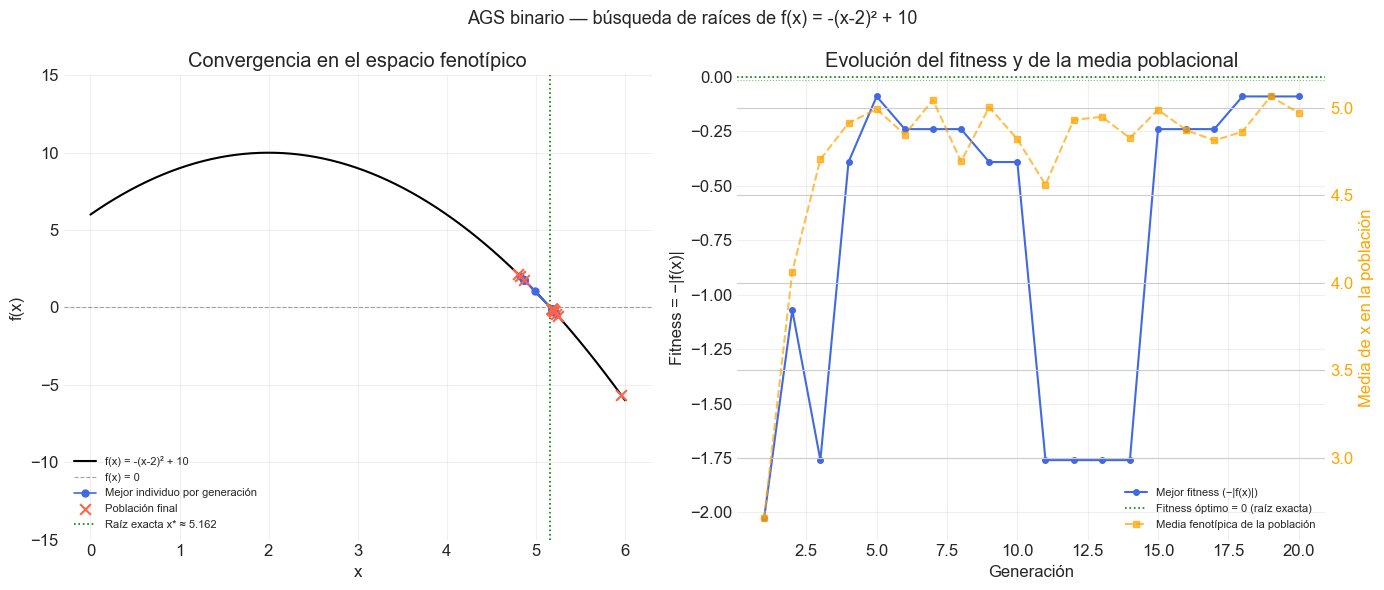

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 3 — Búsqueda de raíces con AGS de codificación binaria
#
# Objetivo: encontrar x* tal que f(x*) = 0, donde f(x) = -(x-2)^2 + 10.
# Las raíces exactas son x = 2 ± √10 ≈ {-1.162, 5.162}.
# Dado que el dominio es [0, 6], la raíz buscada es x* ≈ 5.162.
#
# Estrategia: maximizar fitness(x) = -|f(x)|
#   - fitness = 0   cuando f(x) = 0  →  solución exacta
#   - fitness < 0   en cualquier otro punto
#
# Representación: genotipo binario de N_BITS = 8 bits
#   - 2^8 = 256 valores posibles en [0, 6]
#   - resolución = 6 / 255 ≈ 0.024
#   - los genotipos son legibles en pantalla: permiten "leer" la cadena de bits
#   - aumentar N_BITS mejoraría la resolución sin cambiar ningún operador
# ══════════════════════════════════════════════════════════════════════════════

def f(x):
    return -(x - 2)**2 + 10

def fitness(x):
    # fitness = 0 en la raíz; negativo en cualquier otro punto.
    # Convierte la minimización de |f(x)| en un problema de maximización,
    # compatible con operadores de selección que favorecen valores altos.
    return -np.abs(f(x))

# ── Parámetros ────────────────────────────────────────────────────────────────
N_BITS           = 8      # resolución del genotipo: 2^8 = 256 puntos en [0, 6]
X_MIN, X_MAX     = 0, 6   # dominio de búsqueda
POP_SIZE         = 20     # individuos por generación
GENERATIONS      = 20     # número de ciclos evolutivos
MUTATION_RATE    = 0.02   # probabilidad de flip por bit (8 bits x 0.02 ≈ 0.16 bits mutados/individuo)
SEL_PRESSURE     = 0.5    # sesgo de la distribución de selección

# ── Decodificación ────────────────────────────────────────────────────────────
def decode(bitstring, x_min=X_MIN, x_max=X_MAX):
    """Convierte una cadena de bits en un valor real mediante mapeo lineal."""
    n           = len(bitstring)
    integer_val = int("".join(bitstring.astype(str)), 2)
    return x_min + integer_val * (x_max - x_min) / (2**n - 1)

def decode_population(pop):
    return np.array([decode(ind) for ind in pop])

# ── 1. Inicialización ─────────────────────────────────────────────────────────
# Cada individuo es una cadena aleatoria de N_BITS bits.
# La población cubre el espacio de búsqueda de forma no dirigida.
population = rng.integers(0, 2, size=(POP_SIZE, N_BITS))

# Registros históricos para visualización posterior
history_best_x   = []   # mejor x por generación
history_best_fit = []   # mejor fitness por generación
history_mean_x   = []   # media fenotípica de la población

print("=" * 60)
print("AGS BINARIO — BÚSQUEDA DE RAÍCES DE f(x) = -(x-2)² + 10")
print(f"Dominio: [{X_MIN}, {X_MAX}]  |  Raíz objetivo: x* ≈ 5.162")
print(f"Resolución genotípica: 6 / 255 ≈ {6/255:.4f}  (N_BITS = {N_BITS})")
print("=" * 60)

# ── Bucle evolutivo ───────────────────────────────────────────────────────────
for gen in range(GENERATIONS):

    # ── 2. Decodificación y evaluación ────────────────────────────────────────
    phenotypes = decode_population(population)
    fit_vals   = fitness(phenotypes)

    # Registramos estado de esta generación
    best_idx = np.argmax(fit_vals)
    history_best_x.append(phenotypes[best_idx])
    history_best_fit.append(fit_vals[best_idx])
    history_mean_x.append(np.mean(phenotypes))

    # Informe por generación (cada 5 para no saturar la salida)
    if gen % 5 == 0 or gen == GENERATIONS - 1:
        best_x   = phenotypes[best_idx]
        best_f   = f(best_x)
        best_fit = fit_vals[best_idx]
        print(f"  Gen {gen+1:>3} | mejor x = {best_x:.5f} | f(x) = {best_f:+.5f} | fitness = {best_fit:.5f}")

    # ── 3. Selección (softmax) ────────────────────────────────────────────────
    # Softmax amplifica diferencias de fitness; SEL_PRESSURE controla la
    # intensidad: alto → explotación, bajo → exploración.
    probs  = np.exp(SEL_PRESSURE * fit_vals)
    probs /= probs.sum()
    parent_idx = rng.choice(POP_SIZE, size=POP_SIZE, p=probs)
    parents    = population[parent_idx]

    # ── 4. Cruza de un punto ──────────────────────────────────────────────────
    # Mezclamos para que los pares sean independientes del orden de selección.
    rng.shuffle(parents)
    offspring = []
    for i in range(POP_SIZE // 2):
        p1, p2 = parents[i], parents[i + POP_SIZE // 2]
        # Punto de corte en [1, N_BITS-1]: garantiza al menos un bit de cada padre
        point  = rng.integers(1, N_BITS)
        child1 = np.concatenate([p1[:point], p2[point:]])
        child2 = np.concatenate([p2[:point], p1[point:]])
        offspring.extend([child1, child2])
    offspring = np.array(offspring)

    # ── 5. Mutación (flip de bits) ────────────────────────────────────────────
    # Cada bit se invierte con probabilidad MUTATION_RATE, de forma independiente.
    # Con N_BITS=8 y p=0.02: en promedio 0.16 bits mutados por individuo.
    # La mutación introduce diversidad y evita convergencia prematura.
    mask = rng.random(offspring.shape) < MUTATION_RATE
    offspring[mask] ^= 1   # XOR invierte el bit: 0 → 1 ó 1 → 0

    # ── 6. Reemplazo generacional ─────────────────────────────────────────────
    # La descendencia reemplaza completamente a la generación anterior.
    # Sin elitismo: el mejor individuo puede perderse entre generaciones.
    population = offspring

# Evaluación final de la última generación
phenotypes_final = decode_population(population)
fit_final        = fitness(phenotypes_final)
best_final_x     = phenotypes_final[np.argmax(fit_final)]
best_final_f     = f(best_final_x)

print()
print("=" * 60)
print("RESULTADO FINAL")
print("=" * 60)
print(f"  Mejor x encontrado : {best_final_x:.6f}")
print(f"  f(x)               : {best_final_f:+.6f}  (objetivo: 0.000000)")
print(f"  Error respecto x*  : {abs(best_final_x - (2 + 10**0.5)):.6f}")
print(f"  Raíz exacta        : {2 + 10**0.5:.6f}")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("AGS binario — búsqueda de raíces de f(x) = -(x-2)² + 10", fontsize=13)

# ── Panel izquierdo: paisaje de búsqueda ──────────────────────────────────────
ax = axes[0]
x_plot  = np.linspace(X_MIN, X_MAX, 400)
y_plot  = f(x_plot)

ax.plot(x_plot, y_plot, 'k-', linewidth=1.5, label='f(x) = -(x-2)² + 10')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='f(x) = 0')

# Trayectoria del mejor individuo generación a generación
best_x_arr   = np.array(history_best_x)
best_f_arr   = f(best_x_arr)
ax.plot(best_x_arr, best_f_arr, 'o-', color='royalblue', markersize=5,
        linewidth=1.2, label='Mejor individuo por generación', zorder=3)

# Población final: muestra convergencia o diversidad residual
ax.scatter(phenotypes_final, f(phenotypes_final), marker='x', s=60,
           color='tomato', zorder=4, label='Población final')

# Raíz exacta de referencia
x_root = 2 + 10**0.5
ax.axvline(x_root, color='green', linestyle=':', linewidth=1.2,
           label=f'Raíz exacta x* ≈ {x_root:.3f}')

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Convergencia en el espacio fenotípico')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-15, 15)

# ── Panel derecho: convergencia del fitness ───────────────────────────────────
ax2 = axes[1]
gens = np.arange(1, GENERATIONS + 1)

ax2.plot(gens, history_best_fit, 'o-', color='royalblue', markersize=4,
         label='Mejor fitness (−|f(x)|)')
ax2.axhline(0, color='green', linestyle=':', linewidth=1.2,
            label='Fitness óptimo = 0 (raíz exacta)')

# Eje secundario: evolución de la media fenotípica
ax2b = ax2.twinx()
ax2b.plot(gens, history_mean_x, 's--', color='orange', markersize=4,
          alpha=0.7, label='Media fenotípica de la población')
ax2b.axhline(x_root, color='green', linestyle=':', linewidth=0.8, alpha=0.5)
ax2b.set_ylabel('Media de x en la población', color='orange')
ax2b.tick_params(axis='y', labelcolor='orange')

ax2.set_xlabel('Generación')
ax2.set_ylabel('Fitness = −|f(x)|')
ax2.set_title('Evolución del fitness y de la media poblacional')
ax2.grid(True, alpha=0.3)

# Leyenda combinada de ambos ejes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

### Qué observar en el resultado

La segunda gráfica es la más reveladora. A diferencia de bisección, donde el error cae monótonamente por construcción, aquí la trayectoria del fitness es irregular: hay generaciones donde el mejor individuo no mejora, e incluso puede empeorar si el operador de mutación degrada al mejor padre sin que la selección lo compense.

Lo que sí emerge de forma clara es la **presión de selección acumulada**: la media fenotípica de la población (eje derecho, en naranja) deriva progresivamente hacia la región de la raíz, reflejando que la selección probabilística desplaza el centro de masa poblacional aunque no garantice progreso individual en cada paso.

El salto abrupto de fitness visible en la gráfica es característico de los AGS binarios: ocurre cuando la cruza produce un genotipo que, al decodificarse, cae significativamente más cerca de la raíz que cualquier individuo previo. Es un evento discreto, no una mejora gradual.

El error residual final ($|f(x)| \approx 0.059$) no refleja un fallo del algoritmo sino el **piso de resolución genotípica**: el punto discreto más cercano a la raíz en la grilla de 256 valores dista $\approx 0.009$ de $x^* \approx 5.162$. Bisección, operando en el continuo, puede perforar esa barrera indefinidamente. El AGS binario no puede, y esa diferencia estructural es precisamente lo que la comparación hace visible.

---

## 6. Pool genético y diversidad

La población en cada generación constituye un **pool genético**: un muestreo del espacio de búsqueda que el algoritmo mantiene y transforma iterativamente.

La **diversidad genética** mide la dispersión de los genotipos en ese pool. Es la tensión central de cualquier algoritmo evolutivo:

- Alta diversidad → exploración global del espacio de búsqueda
- Baja diversidad → explotación local de las mejores soluciones conocidas

Esta tensión no se resuelve, se administra. Un algoritmo bien calibrado mantiene suficiente diversidad para no quedar atrapado en óptimos locales, pero concentra progresivamente la búsqueda en las regiones prometedoras.

Los operadores actúan sobre la diversidad de formas opuestas y complementarias:

- **Selección** la reduce: favorece sistemáticamente a los individuos más aptos, empujando a la población hacia regiones de alto fitness.
- **Mutación** la introduce: genera nuevos alelos (variantes en posiciones del genotipo) que no existían en la población actual.
- **Cruza** la redistribuye: no crea información nueva, pero recombina bloques de genotipos existentes, produciendo combinaciones inéditas a partir de material ya presente.

La pérdida irreversible de diversidad se llama **convergencia prematura**: la población colapsa en torno a un óptimo local antes de haber explorado suficientemente el espacio. Es el principal modo de fallo de los AGS, y ocurre cuando la presión de selección supera la capacidad de la mutación para reponer variación.

### El espacio genotípico como espacio de búsqueda real

El algoritmo no opera directamente sobre el espacio del problema sino sobre el **espacio genotípico** inducido por la representación. Esta distinción tiene consecuencias concretas:

- La representación binaria de 8 bits que hemos empleado en nuestros ejemplos previos define una grilla de 256 puntos en el rango $[0, 6]$: ese es el universo accesible, no el continuo real.
- La cruza de un punto opera de forma aparentemente simétrica: elige una posición aleatoria en el genotipo y construye dos hijos intercambiando los segmentos de dos padres. Sin embargo, esta simetría en el espacio genotípico produce una asimetría profunda en el espacio fenotípico que tiene consecuencias directas sobre qué regiones del dominio puede explorar el algoritmo.
- La mutación por flip es simétrica en el espacio genotípico, pero su efecto fenotípico no lo es: invertir el bit más significativo desplaza $x$ hasta en $\approx 3$ unidades, mientras que invertir el menos significativo lo desplaza solo $\approx 0.024$.

Por ello, la elección de representación no es un detalle de implementación sino una **decisión de diseño** que determina qué regiones del espacio son fáciles de alcanzar, qué tan fina puede ser la solución, y qué tipo de estructura puede explotar la cruza.

---

## 7. AGS en paisaje multimodales bidimensional

Hasta ahora el AGS operó sobre $f(x) = -(x-2)^2 + 10$: un paisaje unimodal, continuo y perfectamente bien comportado. En un paisaje unimodal, bisección es mejor opción que un algoritmo genético: converge más rápido, tiene garantías formales y no presenta parámetros que calibrar.

Veamos ahora un par de ejemplos más interesantes.

### Un paisaje multimodal
Consideremos la sigueinte función objetivo:

$$f(x, y) = \sin(x)\cos(2y) + 0.2(x^2 + y^2) + 0.5\sin(3x)\cos(3y)$$

La función objetivo es ahora bidimensional y multimodal. El término $0.2(x^2 + y^2)$ actúa como regularización suave: penaliza soluciones alejadas del origen y garantiza que la función sea acotada en $[-3, 3]^2$, pero no elimina los múltiples mínimos locales introducidos por los términos sinusoidales. 

<p align="center">
  <img src="images/multimodal_function.png" width="80%">
</p>

El paisaje resultante tiene valles, crestas y trampas locales que ningún método determinista basado en información local puede atravesar sin quedar atrapado. En este caso no hay cambio de signo que explotar, no hay gradiente disponible, y el problema tiene dos dimensiones. El AGS, en cambio, opera con la misma lógica de siempre: mantener una población diversa, seleccionar por fitness, recombinar y mutar. El paisaje rugoso no cambia el algoritmo, solo hace visible por qué la diversidad poblacional es necesaria.

La función multimodal ad hoc que estamso utilizando aquí no es una función típica de benchmarking, como lo son Schwefel, Rastrigin, Ackley, Griewank o Rosenbrock. Al no tener un mínimo global conocido ni propiedades analíticas bien caracterizadas (separabilidad, condicionamiento, regularidad, número de óptimos, estructura de cuencas de atracción), no es posible medir error absoluto, distancia al óptimo ni tasa de convergencia real. La evaluación se reduce a observaciones cualitativas: “parece converger”, “explora varias regiones”, “se estanca”. Esto impide comparar configuraciones del algoritmo de forma reproducible. Sin embargo, es más simple que las funciones de trabajo y permite visualizar mejor el esapcio de búsqueda.


### La función de Schwefel

El segundo ejemplo, la función de Schwefel es uno de los benchmarks más utilizados en optimización global. En $d$ dimensiones se define como:

$$f(\mathbf{x}) = 418.9829 \cdot d - \sum_{i=1}^{d} x_i \sin\!\left(\sqrt{|x_i|}\right)$$

con dominio estándar $x_i \in [-500, 500]$ y mínimo global en $x_i^* = 420.9687$ para toda dimensión $i$, donde $f(x^*) = 0$.

<p align="center">
  <img src="images/schwefel_function.png" width="80%">
</p>

El término $418.9829 \cdot d$ es una constante de normalización que desplaza el mínimo global exactamente a cero, facilitando la interpretación del residual como error absoluto.

La función de Schwefel es considerada una de las funciones de prueba más difíciles, lo cuál no es accidental sino estructural. Su dificultad proviene de la interacción entre el término sinusoidal y el dominio amplio. La componente $g(x) = x\sin(\sqrt{|x|})$ tiene una forma característica: oscila con amplitud creciente a medida que $|x|$ aumenta, produciendo una secuencia de valles cada vez más profundos conforme uno se aleja del origen. 


<p align="center">
  <img src="images/schwefel_function_sin.png" width="600">
</p>

El mínimo global de $g$ en $[-500, 500]$ se encuentra en $x \approx 420.97$, pero antes de llegar ahí la función atraviesa decenas de mínimos locales de profundidad comparable.

Esto crea dos propiedades que la hacen especialmente engañosa para los algoritmos de búsqueda:

La primera es la **distancia al óptimo**. El mínimo global está en $x \approx 421$, un valor positivo moderado dentro del dominio. No está en el centro, no está en los bordes, y no hay ninguna característica geométrica obvia que lo distinga de los mínimos locales vecinos a simple vista. Un algoritmo que muestrea el dominio uniformemente no tiene razón estructural para visitar esa región primero.

La segunda es la **topografía engañosa**. Los valles más prominentes visualmente —los más anchos y de paredes más suaves— se encuentran cerca de los extremos del dominio, alrededor de $x \approx \pm 300$ y $x \approx \pm 430$. El gradiente local en esas regiones apunta hacia ellos, no hacia el mínimo global. Un método de descenso de gradiente iniciado desde un punto aleatorio tiene alta probabilidad de terminar en uno de esos valles periféricos sin llegar nunca a $x^* \approx 421$.

En dos dimensiones estas propiedades se combinan de forma multiplicativa: cada dimensión tiene su propio paisaje sinusoidal, y el mínimo global requiere que ambas coordenadas estén simultáneamente cerca de $420.97$. La probabilidad de que una búsqueda local llegue ahí desde un punto arbitrario es baja, lo que hace que la diversidad poblacional inicial sea crítica.

#### Lo que hace verificable el benchmark

A diferencia de funciones construidas ad hoc, Schwefel tiene tres propiedades que la hacen útil como referencia:

El mínimo global es **conocido analíticamente**: $f(420.97, \ldots, 420.97) = 0$. Esto permite medir el error real al final de cada ejecución, no solo el valor de fitness relativo.

Es **escalable en dimensión**: la misma definición funciona en 2, 10, 100 o 1000 dimensiones, lo que permite estudiar cómo degrada el rendimiento del AGS a medida que el espacio crece. En 2D es resoluble con parámetros razonables; en dimensiones altas se convierte en un problema abierto.

Está **ampliamente documentada en la literatura**: existen resultados publicados de decenas de algoritmos distintos sobre esta función, lo que permite comparar directamente sin necesidad de reimplementar métodos alternativos.

Estas propiedades son las que distinguen un benchmark de un ejemplo: no solo ilustra un fenómeno, sino que permite medir, comparar y reproducir.


### Cambios de representación y operadores

Estos ejemplos usan **representación en valores reales** (genotipo = fenotipo) en lugar de codificación binaria para tener un espacio de búsqueda más manejable. En general, en espacios continuos de dimensión moderada, la representación real es más natural y permite operadores con mejor comportamiento geométrico, es decir...

La **selección cambia de softmax a torneo**: en cada selección se eligen $k = 3$ individuos al azar y gana el de mayor fitness. El torneo no requiere calibrar una temperatura y es robusto cuando las diferencias de fitness son muy grandes, situación habitual en paisajes multimodales donde los valles son profundos y los individuos atrapados en ellos tienen fitness muy inferior al de los que están cerca del óptimo global.

La **cruza es por mezcla** (BLX-0 simplificado): cada hijo es una combinación convexa de dos padres con peso aleatorio $\alpha \sim U(0,1)$:

$$\text{hijo} = \alpha \cdot p_1 + (1 - \alpha) \cdot p_2$$

A diferencia de la cruza de un punto, que intercambia segmentos discretos, BLX produce puntos intermedios en el espacio continuo, explorando el segmento entre ambos padres. En dos dimensiones esto tiene un sentido geométrico claro: el hijo cae en algún lugar del segmento que une a sus padres en el plano $(x, y)$. Por ejemplo si $p_1 = (2, 5)$ y $p_2 = (8, 1)$ y si $\alpha = 0.25$:

$$\text{hijo} = 0.25(2,5) + 0.75(8,1) = (6.5, 2)$$

Este punto está sobre la recta que conecta a los padres.

La **mutación es gaussiana**: cada coordenada se perturba con ruido $\mathcal{N}(0, \sigma)$ con probabilidad $p_{\text{mut}}$ independiente. Un $\sigma$ grande explora lejos del padre; un $\sigma$ pequeño refina localmente. A diferencia del flip de bits, cuyo efecto fenotípico depende de la posición del bit mutado, la mutación gaussiana produce perturbaciones de magnitud controlable y predecible en el espacio del problema.

Por último, este ejemplo incorpora **elitismo**: los dos mejores individuos de cada generación pasan directamente a la siguiente sin modificación. Es la estrategia más simple para evitar que la mejor solución encontrada se pierda por deriva generacional, y su efecto es visible en la curva de fitness, que nunca retrocede en el mejor individuo aunque sí puede hacerlo en la media poblacional.

Veamos el algoritmo funcionando:

In [13]:
# ════════════════════════════════════════════════════════════════════════
# AGS en representación real — operadores comunes
# ════════════════════════════════════════════════════════════════════════

def tournament_select(pop, fit_vals, k, rng):
    """Selección por torneo de tamaño k."""
    idx = rng.choice(len(pop), size=k, replace=False)
    return pop[idx[np.argmax(fit_vals[idx])]]

def blx_crossover(p1, p2, rng):
    """Cruza BLX (convexa)."""
    alpha = rng.random()
    return alpha * p1 + (1 - alpha) * p2

def gaussian_mutation(offspring, rate, sigma, xy_min, xy_max, rng):
    """Mutación gaussiana independiente por coordenada."""
    mask      = rng.random(offspring.shape) < rate
    noise     = rng.normal(0, sigma, size=offspring.shape)
    offspring = offspring + mask * noise
    return np.clip(offspring, xy_min, xy_max)

def run_ags(fitness_fn, xy_min, xy_max, pop_size, generations,
            mutation_sigma, mutation_rate, tournament_k, elite_n,
            snap_gens, seed=42):

    rng        = np.random.default_rng(seed)
    population = rng.uniform(xy_min, xy_max, size=(pop_size, 2))

    history_best_fit  = []
    history_mean_fit  = []
    history_worst_fit = []
    history_best_xy   = []
    history_diversity = []
    snapshots         = {}

    for gen in range(generations):

        fit_vals  = fitness_fn(population)
        best_idx  = np.argmax(fit_vals)
        diversity = np.mean(np.std(population, axis=0))

        history_best_fit.append(fit_vals[best_idx])
        history_mean_fit.append(fit_vals.mean())
        history_worst_fit.append(fit_vals.min())
        history_best_xy.append(population[best_idx].copy())
        history_diversity.append(diversity)

        if gen in snap_gens:
            snapshots[gen] = population.copy()

        elite_idx = np.argsort(fit_vals)[-elite_n:]
        elites    = population[elite_idx].copy()

        offspring = []
        for _ in range(pop_size - elite_n):
            p1    = tournament_select(population, fit_vals, tournament_k, rng)
            p2    = tournament_select(population, fit_vals, tournament_k, rng)
            child = blx_crossover(p1, p2, rng)
            offspring.append(child)
        offspring = np.array(offspring)

        offspring = gaussian_mutation(offspring, mutation_rate, mutation_sigma,
                                      xy_min, xy_max, rng)

        population = np.vstack([elites, offspring])

    fit_final = fitness_fn(population)
    snapshots[generations - 1] = population.copy()

    return {
        'history_best_fit' : history_best_fit,
        'history_mean_fit' : history_mean_fit,
        'history_worst_fit': history_worst_fit,
        'history_best_xy'  : np.array(history_best_xy),
        'history_diversity': history_diversity,
        'snapshots'        : snapshots,
        'final_population' : population,
        'final_fit'        : fit_final,
    }

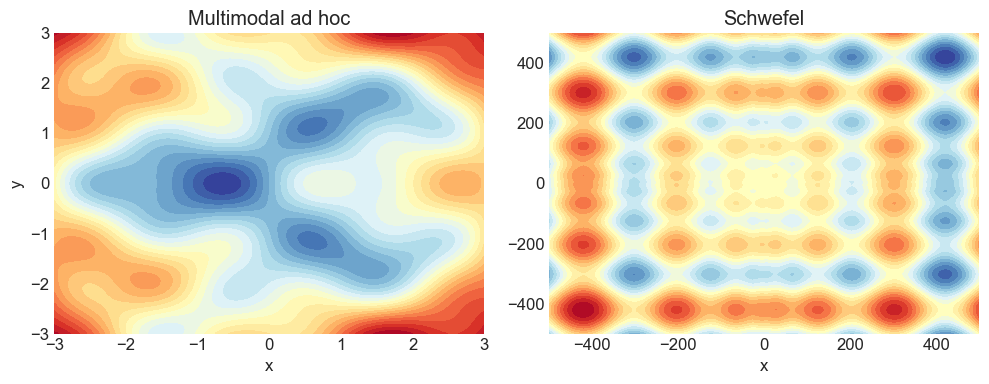

In [14]:
# ════════════════════════════════════════════════════════════════════════
# Funciones objetivo
# ════════════════════════════════════════════════════════════════════════

def f_multimodal(x, y):
    return np.sin(x) * np.cos(2*y) + 0.2*(x**2 + y**2) + 0.5*np.sin(3*x)*np.cos(3*y)

def f_schwefel(xy):
    d   = len(xy)
    return 418.9829 * d - np.sum(xy * np.sin(np.sqrt(np.abs(xy))))

def f_schwefel_2d(x, y):
    return 418.9829 * 2 - (x * np.sin(np.sqrt(np.abs(x))) +
                           y * np.sin(np.sqrt(np.abs(y))))

# ── Visualización de las tres funciones ─────────────────────────────────

fig = plt.figure(figsize=(15, 4))

# Multimodal ad hoc
ax1 = fig.add_subplot(1, 3, 1)
gx = np.linspace(-3, 3, 200)
gy = np.linspace(-3, 3, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = f_multimodal(GX, GY)
ax1.contourf(GX, GY, GZ, levels=25, cmap='RdYlBu_r')
ax1.set_title("Multimodal ad hoc")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# Schwefel (vista local reducida para comparar forma)
ax2 = fig.add_subplot(1, 3, 2)
gx = np.linspace(-500, 500, 200)
gy = np.linspace(-500, 500, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = f_schwefel_2d(GX, GY)
ax2.contourf(GX, GY, GZ, levels=25, cmap='RdYlBu_r')
ax2.set_title("Schwefel")
ax2.set_xlabel("x")


plt.tight_layout()
plt.show()


Las superficies mostradas en estas  gráficas corresponden a dos paisajes de aptitud con propiedades distintas y objetivos complementarios dentro del análisis del algoritmo genético.

En la primera gráfica se observa una superficie suave, continua y claramente multimodal. La combinación de términos sinusoidales genera una estructura ondulada con múltiples valles y crestas, mientras que el término cuadrático introduce una tendencia global creciente hacia los bordes del dominio.

Visualmente se distinguen:

- Varios **mínimos locales** distribuidos de forma regular  
- Cuencas de atracción amplias y relativamente suaves  
- Un gradiente bien definido dentro de cada valle  
- Interacción entre variables $x$ y $y$, lo que produce patrones diagonales en la superficie  

El mínimo global no está caracterizado analíticamente, pero en la gráfica puede identificarse como el valle más profundo dentro de la región central. 

La segunda gráfica muestra un paisaje mucho más engañoso. Aunque la superficie parece relativamente suave, los **mínimos locales dominantes** se encuentran lejos del mínimo global. Además, el óptimo no está en el centro del dominio sino desplazado hacia una región específica.

En la visualización se aprecia que:

- las zonas cercanas a los bordes presentan pendientes poco informativas  
- existen valles profundos que no conducen al óptimo global  
- la topología global no es intuitiva a partir de la información local  

El resutado dle algoritmo genético sobre la función multimodale es

In [15]:
# ════════════════════════════════════════════════════════════════════════
# Función multimodal simple
# ════════════════════════════════════════════════════════════════════════

A_MIN, A_MAX = -3.0, 3.0
A_POP        = 40
A_GENS       = 40
A_SIGMA      = 0.3
A_MUT_RATE   = 0.4
A_K          = 3
A_ELITE      = 2
A_SNAPS      = [0, 1, 3, 8, 20, A_GENS - 1]

def fitness_multimodal(pop):
    return -f_multimodal(pop[:, 0], pop[:, 1])

res_A = run_ags(fitness_multimodal, A_MIN, A_MAX,
                A_POP, A_GENS, A_SIGMA, A_MUT_RATE,
                A_K, A_ELITE, A_SNAPS)

best_A    = res_A['final_population'][np.argmax(res_A['final_fit'])]
f_best_A  = f_multimodal(best_A[0], best_A[1])

print("Mejor solución multimodal:")
print(f"x = {best_A[0]:+.5f}, y = {best_A[1]:+.5f}")
print(f"f(x,y) = {f_best_A:+.6f}")

Mejor solución multimodal:
x = -0.64588, y = -0.00010
f(x,y) = -0.985201


Este resultado indica que el algoritmo genético logró concentrar la población en una de las cuencas más profundas observadas en la gráfica 3D de la función *ad hoc*. Al comparar visualmente la superficie, ese punto coincide con el valle más pronunciado dentro de la región central del dominio, lo que sugiere una convergencia efectiva hacia el mejor mínimo accesible durante la búsqueda. Dado que la función no tiene un óptimo global conocido, no puede asegurarse que sea el mínimo absoluto, pero sí que corresponde al valle más profundo identificado por el algoritmo en las visualizaciones.

El resultado sobre la función de Schwefel, por otra parte es

In [16]:
# ════════════════════════════════════════════════════════════════════════
# Función de Schwefel
# ════════════════════════════════════════════════════════════════════════

B_MIN, B_MAX = -500.0, 500.0
B_POP        = 150
B_GENS       = 150
B_SIGMA      = 100.0
B_MUT_RATE   = 0.5
B_K          = 3
B_ELITE      = 3
B_SNAPS      = [0, 1, 10, 30, 80, B_GENS - 1]
SCHWEFEL_OPTIMUM = np.array([420.9687, 420.9687])

def fitness_schwefel(pop):
    return np.array([-f_schwefel(ind) for ind in pop])

res_B = run_ags(fitness_schwefel, B_MIN, B_MAX,
                B_POP, B_GENS, B_SIGMA, B_MUT_RATE,
                B_K, B_ELITE, B_SNAPS)

best_B   = res_B['final_population'][np.argmax(res_B['final_fit'])]
f_best_B = f_schwefel(best_B)
err_B    = np.linalg.norm(best_B - SCHWEFEL_OPTIMUM)

print("Mejor solución Schwefel:")
print(f"x = {best_B[0]:+.3f}, y = {best_B[1]:+.3f}")
print(f"f(x,y) = {f_best_B:+.4f}")
print(f"Error a x* = {err_B:.3f}")

Mejor solución Schwefel:
x = +421.015, y = +420.909
f(x,y) = +0.0008
Error a x* = 0.076


Este resultado muestra que el algoritmo genético convergió muy cerca del mínimo global conocido de la función de Schwefel en $(420.9687,\;420.9687)$. El error euclidiano reportado ($0.076$) indica que la solución encontrada se ubica dentro de una vecindad muy pequeña del óptimo, lo que confirma una búsqueda efectiva en un paisaje altamente engañoso. Dado que los mínimos locales dominantes de Schwefel se encuentran alejados del óptimo global, este resultado sugiere que el algoritmo mantuvo suficiente diversidad poblacional para evitar la convergencia prematura y logró explotar correctamente la región óptima en las últimas generaciones.

Exploremos la evolución de las soluciones en ambos casos:

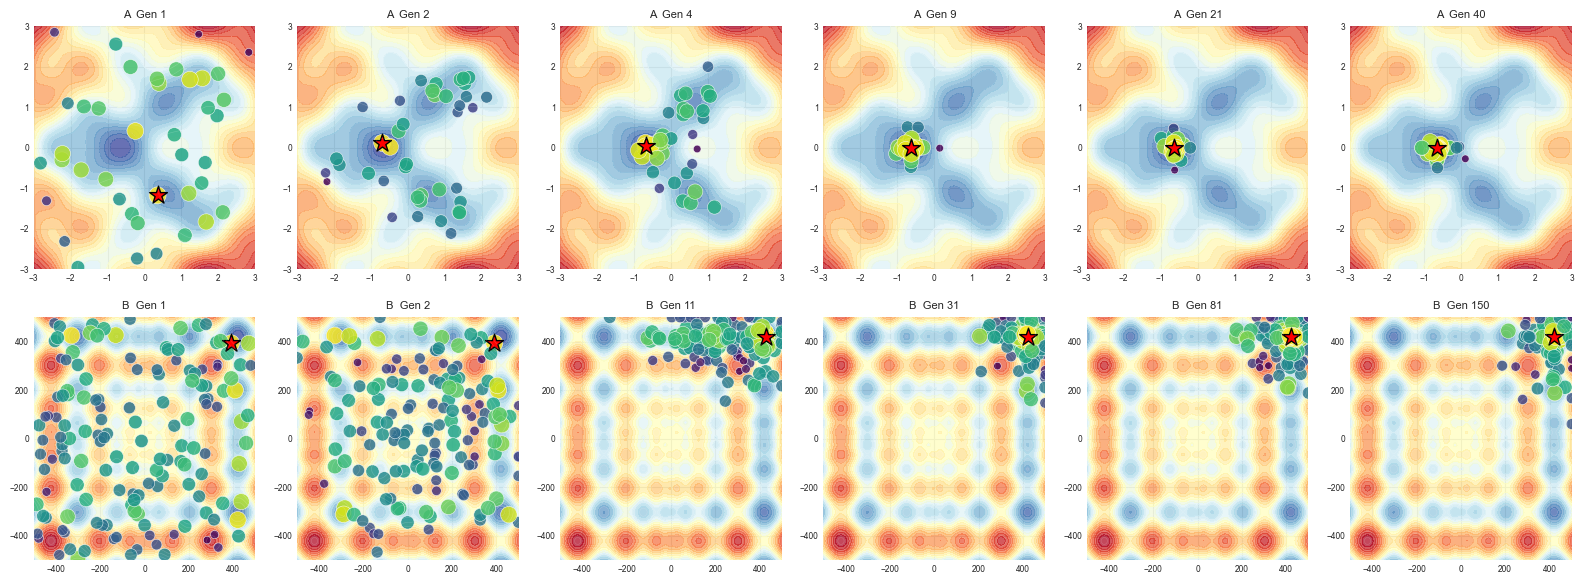

In [17]:
# ════════════════════════════════════════════════════════════════════════
# Instantáneas evolutivas sobre ambos paisajes
# ════════════════════════════════════════════════════════════════════════

def plot_snapshots(fig, row_offset, snap_gens, snapshots, GX, GY, GZ,
                   fitness_fn, xy_min, xy_max, label):
    n = len(snap_gens)
    for col, gen in enumerate(snap_gens):
        ax       = fig.add_subplot(2, n, row_offset * n + col + 1)
        pop_snap = snapshots[gen]
        fit_snap = fitness_fn(pop_snap)
        best_s   = pop_snap[np.argmax(fit_snap)]

        ax.contourf(GX, GY, GZ, levels=25, cmap='RdYlBu_r', alpha=0.75)
        ax.contour(GX, GY, GZ,  levels=12, colors='white', alpha=0.2, linewidths=0.4)

        fit_range = fit_snap.max() - fit_snap.min() + 1e-10
        sizes     = 30 + 120 * (fit_snap - fit_snap.min()) / fit_range

        ax.scatter(pop_snap[:, 0], pop_snap[:, 1],
                   s=sizes, c=fit_snap, cmap='viridis',
                   edgecolors='white', linewidth=0.4, alpha=0.85)

        ax.scatter(best_s[0], best_s[1],
                   s=180, color='red', marker='*',
                   edgecolors='black', linewidth=1)

        ax.set_title(f"{label}  Gen {gen+1}", fontsize=8)
        ax.set_xlim(xy_min, xy_max)
        ax.set_ylim(xy_min, xy_max)
        ax.tick_params(labelsize=6)

# Grillas de fondo (si no existen en memoria)
gx_A, gy_A = np.linspace(A_MIN, A_MAX, 200), np.linspace(A_MIN, A_MAX, 200)
GXA, GYA   = np.meshgrid(gx_A, gy_A)
GZA        = f_multimodal(GXA, GYA)

gx_B, gy_B = np.linspace(B_MIN, B_MAX, 200), np.linspace(B_MIN, B_MAX, 200)
GXB, GYB   = np.meshgrid(gx_B, gy_B)
GZB        = f_schwefel_2d(GXB, GYB)

fig = plt.figure(figsize=(16, 6))

plot_snapshots(fig, 0, A_SNAPS, res_A['snapshots'],
               GXA, GYA, GZA, fitness_multimodal, A_MIN, A_MAX, "A")

plot_snapshots(fig, 1, B_SNAPS, res_B['snapshots'],
               GXB, GYB, GZB, fitness_schwefel, B_MIN, B_MAX, "B")

plt.tight_layout()
plt.show()

Las instantáneas permiten observar la dinámica poblacional. El tamaño del marcador codifica fitness relativo y la estrella identifica al mejor individuo. En la función ad hoc se aprecia la rápida concentración en una cuenca. En Schwefel la población permanece dispersa durante más generaciones debido a la necesidad de exploración global antes de la explotación local.

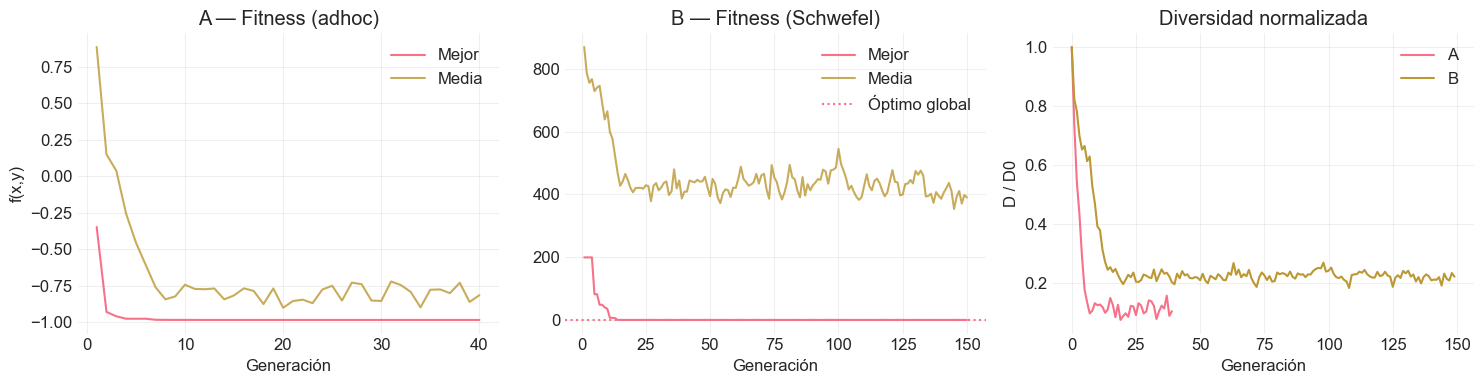

In [18]:
# ════════════════════════════════════════════════════════════════════════
# Evolución del fitness y pérdida de diversidad
# ════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Parte A — fitness
gens_A = np.arange(1, A_GENS + 1)
bA = -np.array(res_A['history_best_fit'])
mA = -np.array(res_A['history_mean_fit'])
wA = -np.array(res_A['history_worst_fit'])

axes[0].plot(gens_A, bA, label='Mejor')
axes[0].plot(gens_A, mA, label='Media', alpha=0.8)
axes[0].set_title('A — Fitness (adhoc)')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('f(x,y)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parte B — fitness
gens_B = np.arange(1, B_GENS + 1)
bB = -np.array(res_B['history_best_fit'])
mB = -np.array(res_B['history_mean_fit'])
wB = -np.array(res_B['history_worst_fit'])

axes[1].plot(gens_B, bB, label='Mejor')
axes[1].plot(gens_B, mB, label='Media', alpha=0.8)
axes[1].axhline(0, linestyle=':', label='Óptimo global')
axes[1].set_title('B — Fitness (Schwefel)')
axes[1].set_xlabel('Generación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Diversidad normalizada
divA = np.array(res_A['history_diversity'])
divB = np.array(res_B['history_diversity'])

axes[2].plot(divA / divA[0], label='A')
axes[2].plot(divB / divB[0], label='B')
axes[2].set_title('Diversidad normalizada')
axes[2].set_xlabel('Generación')
axes[2].set_ylabel('D / D0')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas de fitness permiten observar la dinámica de explotación del algoritmo a lo largo de las generaciones. La trayectoria del **mejor fitness** muestra la capacidad del algoritmo para encontrar soluciones cada vez más profundas dentro del paisaje: descensos rápidos indican descubrimiento de cuencas prometedoras, mientras que mesetas sugieren estancamiento local. La **media poblacional** refleja el desplazamiento global de la población hacia regiones de mayor calidad, y la **distancia entre la curva del mejor y la media** funciona como un indicador de presión selectiva: cuando la brecha es grande, pocos individuos dominan la población; cuando se reduce, la población se ha concentrado en una misma cuenca.

En la función *ad hoc* se observa típicamente una caída rápida del mejor fitness seguida de una convergencia temprana, acompañada por una reducción acelerada de la diversidad normalizada. Esto indica que la población identifica pronto un valle dominante y colapsa alrededor de él, favoreciendo la explotación sobre la exploración.

En el caso de Schwefel, la mejora del fitness es más gradual y la brecha entre mejor y media persiste durante más generaciones. La **diversidad decrece más lentamente**, lo que evidencia que el algoritmo mantiene múltiples regiones activas del espacio de búsqueda antes de concentrarse en el óptimo. Este comportamiento es consistente con un paisaje engañoso, donde la exploración sostenida es necesaria para evitar mínimos locales dominantes alejados del óptimo global.

----

---

<p align="center">
  <img src="images/exhausted.png" width="500">
</p>

## 5. Selección: Cómo Decide un Algoritmo Genético

### Comparativa de Métodos de Selección

La selección es el mecanismo que determina qué individuos se reproducen. Es el motor de la **presión selectiva**.

In [ ]:
# COMPARATIVA DE MÉTODOS DE SELECCIÓN
# ===================================

def simulacion_seleccion(fitness, metodo='ruleta', tam_poblacion=1000, k_torneo=3):
    """Simula la distribución de selección de un método."""
    conteo = np.zeros(len(fitness))
    
    if metodo == 'ruleta':
        # Fitness ajustado para minimización
        fitness_ajustado = np.max(fitness) - fitness + 1e-10
        probabilidades = fitness_ajustado / np.sum(fitness_ajustado)
        
        for _ in range(tam_poblacion):
            idx = np.random.choice(len(fitness), p=probabilidades)
            conteo[idx] += 1
            
    elif metodo == 'torneo':
        for _ in range(tam_poblacion):
            competidores = np.random.choice(len(fitness), k_torneo, replace=False)
            ganador = competidores[np.argmin(fitness[competidores])]
            conteo[ganador] += 1
            
    elif metodo == 'ranking':
        # Ordenar por fitness (mejores primero)
        indices_ordenados = np.argsort(fitness)
        # Probabilidad lineal decreciente
        probabilidades = np.linspace(1.5, 0.5, len(fitness))
        probabilidades = probabilidades / np.sum(probabilidades)
        
        # Mapear probabilidades a índices originales
        prob_por_indice = np.zeros(len(fitness))
        for i, idx in enumerate(indices_ordenados):
            prob_por_indice[idx] = probabilidades[i]
            
        for _ in range(tam_poblacion):
            idx = np.random.choice(len(fitness), p=prob_por_indice)
            conteo[idx] += 1
    
    return conteo / tam_poblacion  # Frecuencia relativa

# Crear población de ejemplo
np.random.seed(42)
fitness_ejemplo = np.array([10, 8, 6, 4, 2, 1, 0.5, 0.2, 0.1, 0.05])
individuos = [f'Ind{i+1}' for i in range(len(fitness_ejemplo))]

# Simular diferentes métodos
metodos = ['ruleta', 'torneo', 'ranking']
resultados = {}

for metodo in metodos:
    resultados[metodo] = simulacion_seleccion(fitness_ejemplo, metodo=metodo, tam_poblacion=10000)

# VISUALIZACIÓN COMPARATIVA
# =========================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Gráfico 1: Fitness original
axes[0, 0].bar(individuos, fitness_ejemplo, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Individuo', fontsize=12)
axes[0, 0].set_ylabel('Fitness (a minimizar)', fontsize=12)
axes[0, 0].set_title('Fitness Original de la Población', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Gráficos de distribución de selección
for idx, metodo in enumerate(metodos):
    ax = axes[0, idx+1] if idx < 2 else axes[1, 0]
    
    barras = ax.bar(individuos, resultados[metodo], 
                   color=['red', 'orange', 'green'][idx], 
                   edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Individuo', fontsize=12)
    ax.set_ylabel('Frecuencia de selección', fontsize=12)
    ax.set_title(f'Selección: {metodo.upper()}', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Anotar estadísticas
    mejor_idx = np.argmin(fitness_ejemplo)
    frecuencia_mejor = resultados[metodo][mejor_idx]
    ax.text(0.05, 0.95, f'Mejor individuo: {frecuencia_mejor:.1%}', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Gráfico 4: Comparación lado a lado
x = np.arange(len(individuos))
ancho = 0.25

axes[1, 1].bar(x - ancho, resultados['ruleta'], width=ancho, 
              label='Ruleta', color='red', alpha=0.7, edgecolor='black')
axes[1, 1].bar(x, resultados['torneo'], width=ancho, 
              label='Torneo (k=3)', color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].bar(x + ancho, resultados['ranking'], width=ancho, 
              label='Ranking', color='green', alpha=0.7, edgecolor='black')

axes[1, 1].set_xlabel('Individuo', fontsize=12)
axes[1, 1].set_ylabel('Frecuencia de selección', fontsize=12)
axes[1, 1].set_title('Comparación de Métodos de Selección', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(individuos, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Gráfico 5: Presión selectiva vs diversidad
axes[1, 2].plot([1, 2, 3], [0.3, 0.5, 0.7], 'ro-', linewidth=3, markersize=10, label='Ruleta')
axes[1, 2].plot([1, 2, 3], [0.2, 0.4, 0.9], 'go-', linewidth=3, markersize=10, label='Torneo (k variable)')
axes[1, 2].plot([1, 2, 3], [0.25, 0.35, 0.45], 'bo-', linewidth=3, markersize=10, label='Ranking')

axes[1, 2].set_xlabel('Presión Selectiva (1=baja, 3=alta)', fontsize=12)
axes[1, 2].set_ylabel('Pérdida de Diversidad (0-1)', fontsize=12)
axes[1, 2].set_title('Trade-off: Presión Selectiva vs Diversidad', fontsize=14, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xticks([1, 2, 3])
axes[1, 2].set_xticklabels(['Baja', 'Media', 'Alta'])

plt.tight_layout()
plt.show()

# ANÁLISIS CUANTITATIVO
# =====================
print("\n" + "="*80)
print("ANÁLISIS COMPARATIVO DE MÉTODOS DE SELECCIÓN")
print("="*80)

# Calcular métricas
def calcular_metricas(frecuencias, fitness):
    """Calcula métricas de calidad de selección."""
    # 1. Probabilidad del mejor individuo
    mejor_idx = np.argmin(fitness)
    prob_mejor = frecuencias[mejor_idx]
    
    # 2. Entropía (diversidad)
    entropia = -np.sum(frecuencias * np.log(frecuencias + 1e-10))
    entropia_max = np.log(len(fitness))
    diversidad_normalizada = entropia / entropia_max
    
    # 3. Eficiencia (correlación fitness-probabilidad)
    # Fitness normalizado (mejor = 1, peor = 0)
    fitness_norm = 1 - (fitness - np.min(fitness)) / (np.max(fitness) - np.min(fitness) + 1e-10)
    correlacion = np.corrcoef(fitness_norm, frecuencias)[0, 1]
    
    return {
        'prob_mejor': prob_mejor,
        'diversidad': diversidad_normalizada,
        'correlacion': correlacion
    }

print("\n📊 MÉTRICAS DE CALIDAD POR MÉTODO:")
print("-" * 60)
print(f"{'Método':<10} {'Prob. Mejor':<15} {'Diversidad':<15} {'Correlación':<15}")
print("-" * 60)

for metodo in metodos:
    metricas = calcular_metricas(resultados[metodo], fitness_ejemplo)
    print(f"{metodo:<10} {metricas['prob_mejor']:<15.3f} {metricas['diversidad']:<15.3f} {metricas['correlacion']:<15.3f}")

print("\n💡 INTERPRETACIÓN:")
print("1. RULETA: Alta presión selectiva, baja diversidad")
print("2. TORNEO: Balanceado, controlable con k")
print("3. RANKING: Más diversidad, menos presión extrema")

print("\n🎯 RECOMENDACIONES PRÁCTICAS:")
print("• Ruleta: Problemas simples, convergencia rápida")
print("• Torneo: Problemas complejos, control preciso de presión")
print("• Ranking: Cuando hay valores de fitness extremos o ruido")

print("\n⚠️  ELITISMO: SIEMPRE activar. Garantiza que nunca perdamos la mejor solución.")

## 6. Operadores de Cruza: Cómo se Recombinan las Soluciones

### Tipos de Operadores de Cruza

La cruza define cómo combinamos información de dos padres para crear descendencia.

In [ ]:
# VISUALIZACIÓN DE OPERADORES DE CRUZA
# ====================================

def visualizar_cruza(padre1, padre2, dimensiones=10):
    """Visualiza diferentes operadores de cruza."""
    
    # Crear figura
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Operadores de Cruza - Comparativa Visual', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # 1. CRUZA EN UN PUNTO
    ax = axes[0, 0]
    punto = np.random.randint(1, dimensiones-1)
    hijo = np.concatenate([padre1[:punto], padre2[punto:]])
    
    ax.bar(range(dimensiones), padre1, alpha=0.5, color='blue', label='Padre 1')
    ax.bar(range(dimensiones), padre2, alpha=0.5, color='red', label='Padre 2')
    ax.bar(range(dimensiones), hijo, alpha=0.8, color='green', label='Hijo', width=0.4)
    ax.axvline(punto-0.5, color='black', linestyle='--', linewidth=2, label='Punto de cruza')
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title('Cruza en un Punto', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. CRUZA EN DOS PUNTOS
    ax = axes[0, 1]
    puntos = sorted(np.random.choice(range(1, dimensiones), 2, replace=False))
    punto1, punto2 = puntos
    
    hijo = np.concatenate([padre1[:punto1], 
                          padre2[punto1:punto2], 
                          padre1[punto2:]])
    
    ax.bar(range(dimensiones), padre1, alpha=0.5, color='blue', label='Padre 1')
    ax.bar(range(dimensiones), padre2, alpha=0.5, color='red', label='Padre 2')
    ax.bar(range(dimensiones), hijo, alpha=0.8, color='green', label='Hijo', width=0.4)
    ax.axvline(punto1-0.5, color='black', linestyle='--', linewidth=2, label='Puntos de cruza')
    ax.axvline(punto2-0.5, color='black', linestyle='--', linewidth=2)
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_title('Cruza en Dos Puntos', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. CRUZA UNIFORME
    ax = axes[0, 2]
    mascara = np.random.random(dimensiones) < 0.5
    hijo = np.where(mascara, padre1, padre2)
    
    # Colores por origen
    colores = ['blue' if m else 'red' for m in mascara]
    
    ax.bar(range(dimensiones), padre1, alpha=0.3, color='blue', label='Padre 1')
    ax.bar(range(dimensiones), padre2, alpha=0.3, color='red', label='Padre 2')
    
    for i in range(dimensiones):
        ax.bar(i, hijo[i], color=colores[i], alpha=0.8, width=0.4)
    
    # Leyenda personalizada
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', alpha=0.8, label='Gen de Padre 1'),
        Patch(facecolor='red', alpha=0.8, label='Gen de Padre 2')
    ]
    ax.legend(handles=legend_elements)
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_title('Cruza Uniforme', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. CRUZA ARITMÉTICA (para representación real)
    ax = axes[1, 0]
    alpha = np.random.random()
    hijo = alpha * padre1 + (1 - alpha) * padre2
    
    ax.plot(range(dimensiones), padre1, 'b-o', linewidth=2, markersize=6, label='Padre 1', alpha=0.6)
    ax.plot(range(dimensiones), padre2, 'r-o', linewidth=2, markersize=6, label='Padre 2', alpha=0.6)
    ax.plot(range(dimensiones), hijo, 'g-s', linewidth=3, markersize=8, label=f'Hijo (α={alpha:.2f})', alpha=0.8)
    
    # Sombrear área entre padres
    ax.fill_between(range(dimensiones), padre1, padre2, alpha=0.1, color='gray', label='Espacio entre padres')
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title('Cruza Aritmética', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. CRUZA BLX-α (BLend Crossover)
    ax = axes[1, 1]
    alpha_blx = 0.3
    
    # Calcular intervalo extendido
    c_min = np.minimum(padre1, padre2)
    c_max = np.maximum(padre1, padre2)
    I = c_max - c_min
    
    # Intervalo extendido
    lower = c_min - alpha_blx * I
    upper = c_max + alpha_blx * I
    
    # Generar hijo aleatorio en intervalo
    hijo_blx = np.random.uniform(lower, upper)
    
    ax.plot(range(dimensiones), padre1, 'b-o', linewidth=2, markersize=6, label='Padre 1', alpha=0.6)
    ax.plot(range(dimensiones), padre2, 'r-o', linewidth=2, markersize=6, label='Padre 2', alpha=0.6)
    
    # Mostrar intervalos
    for i in range(dimensiones):
        ax.plot([i, i], [lower[i], upper[i]], 'k-', linewidth=1, alpha=0.3)
        ax.plot(i, hijo_blx[i], 'gs', markersize=10, alpha=0.8)
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_title(f'Cruza BLX-α (α={alpha_blx})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. SIMULATED BINARY CROSSOVER (SBX)
    ax = axes[1, 2]
    eta = 2.0  # Parámetro de distribución
    
    def sbx_beta(u, eta):
        """Calcula factor beta para SBX."""
        if u <= 0.5:
            return (2*u)**(1/(eta+1))
        else:
            return (1/(2*(1-u)))**(1/(eta+1))
    
    hijo1_sbx = np.zeros(dimensiones)
    hijo2_sbx = np.zeros(dimensiones)
    
    for i in range(dimensiones):
        u = np.random.random()
        beta = sbx_beta(u, eta)
        hijo1_sbx[i] = 0.5 * ((1+beta)*padre1[i] + (1-beta)*padre2[i])
        hijo2_sbx[i] = 0.5 * ((1-beta)*padre1[i] + (1+beta)*padre2[i])
    
    ax.plot(range(dimensiones), padre1, 'b-o', linewidth=2, markersize=6, label='Padre 1', alpha=0.6)
    ax.plot(range(dimensiones), padre2, 'r-o', linewidth=2, markersize=6, label='Padre 2', alpha=0.6)
    ax.plot(range(dimensiones), hijo1_sbx, 'g-s', linewidth=3, markersize=8, label='Hijo 1 SBX', alpha=0.8)
    ax.plot(range(dimensiones), hijo2_sbx, 'm-^', linewidth=3, markersize=8, label='Hijo 2 SBX', alpha=0.8)
    
    # Línea entre padres
    ax.fill_between(range(dimensiones), padre1, padre2, alpha=0.1, color='gray')
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_title(f'Simulated Binary Crossover (η={eta})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        '1_punto': hijo,
        '2_puntos': hijo,
        'uniforme': hijo,
        'aritmetica': hijo,
        'blx': hijo_blx,
        'sbx': (hijo1_sbx, hijo2_sbx)
    }

# Generar padres de ejemplo
np.random.seed(42)
dim = 10
padre1 = np.random.uniform(0, 10, dim)
padre2 = np.random.uniform(0, 10, dim)

print("🔬 GENERANDO PADRES DE EJEMPLO:")
print(f"Padre 1: {padre1.round(2)}")
print(f"Padre 2: {padre2.round(2)}")
print()

hijos = visualizar_cruza(padre1, padre2, dimensiones=dim)

# ANÁLISIS DE LOS OPERADORES
# ==========================
print("\n" + "="*80)
print("ANÁLISIS DE OPERADORES DE CRUZA")
print("="*80)

print("\n📊 CARACTERÍSTICAS DE CADA OPERADOR:")

caracteristicas = {
    "Cruza en un punto": {
        "Complejidad": "Baja",
        "Exploración": "Media",
        "Explotación": "Alta",
        "Recomendado para": "Representaciones binarias/discretas",
        "Ventaja": "Simple, mantiene bloques de genes"
    },
    "Cruza en dos puntos": {
        "Complejidad": "Baja",
        "Exploración": "Media-Alta",
        "Explotación": "Media",
        "Recomendado para": "Representaciones binarias/discretas",
        "Ventaja": "Más diversidad que un punto"
    },
    "Cruza uniforme": {
        "Complejidad": "Baja",
        "Exploración": "Alta",
        "Explotación": "Baja",
        "Recomendado para": "Problemas sin epistasis fuerte",
        "Ventaja": "Máxima recombinación"
    },
    "Cruza aritmética": {
        "Complejidad": "Media",
        "Exploración": "Baja",
        "Explotación": "Alta",
        "Recomendado para": "Optimización continua",
        "Ventaja": "Suave, buen refinamiento"
    },
    "BLX-α": {
        "Complejidad": "Media",
        "Exploración": "Alta",
        "Explotación": "Media",
        "Recomendado para": "Optimización continua multimodal",
        "Ventaja": "Explora alrededor de padres"
    },
    "SBX": {
        "Complejidad": "Alta",
        "Exploración": "Media",
        "Explotación": "Alta",
        "Recomendado para": "Optimización continua",
        "Ventaja": "Distribución controlada, teóricamente sólida"
    }
}

print("-" * 100)
print(f"{'Operador':<25} {'Complejidad':<12} {'Exploración':<12} {'Explotación':<12} {'Recomendado para':<30}")
print("-" * 100)

for nombre, info in caracteristicas.items():
    print(f"{nombre:<25} {info['Complejidad']:<12} {info['Exploración']:<12} {info['Explotación']:<12} {info['Recomendado para']:<30}")

print("\n💡 REGLAS PRÁCTICAS:")
print("1. Empieza simple: cruza en un punto o uniforme")
print("2. Para optimización continua: usa BLX-α o SBX")
print("3. Si la convergencia es muy rápida: aumenta exploración (más puntos, BLX-α)")
print("4. Si la convergencia es muy lenta: aumenta explotación (aritmética, SBX)")

# ESTUDIO DE EPISTASIS
# ====================
print("\n🧬 CONCEPTO CLAVE: EPISTASIS")
print("La epistasis se refiere a interacciones entre genes.")
print("• Alta epistasis: Genes interactúan fuertemente (ej: TSP)")
print("• Baja epistasis: Genes son independientes (ej: suma de funciones)")
print("\n📈 IMPLICACIONES:")
print("• Alta epistasis: Usar cruza que preserve bloques (1 o 2 puntos)")
print("• Baja epistasis: Usar cruza que recombine libremente (uniforme, aritmética)")

## 7. Mutación: El Motor de la Diversidad

### Tipos de Operadores de Mutación

La mutación introduce variación aleatoria, evita convergencia prematura y mantiene diversidad.

In [ ]:
# VISUALIZACIÓN DE OPERADORES DE MUTACIÓN
# =======================================

def visualizar_mutaciones(individuo_original, dimensiones=20):
    """Visualiza diferentes operadores de mutación."""
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Operadores de Mutación - Comparativa Visual', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # 1. MUTACIÓN BINARIA (BIT FLIP)
    ax = axes[0, 0]
    # Convertir a binario para ejemplo
    individuo_bin = (individuo_original > 5).astype(int)
    
    # Aplicar mutación
    individuo_mutado = individuo_bin.copy()
    prob_mut = 0.2
    for i in range(dimensiones):
        if np.random.random() < prob_mut:
            individuo_mutado[i] = 1 - individuo_mutado[i]  # Flip bit
    
    # Visualizar
    x_pos = np.arange(dimensiones)
    ax.bar(x_pos - 0.2, individuo_bin, width=0.4, alpha=0.6, color='blue', label='Original')
    ax.bar(x_pos + 0.2, individuo_mutado, width=0.4, alpha=0.8, color='red', label='Mutado')
    
    # Marcar bits mutados
    bits_mutados = np.where(individuo_bin != individuo_mutado)[0]
    for bit in bits_mutados:
        ax.text(bit, max(individuo_bin[bit], individuo_mutado[bit]) + 0.1, '⚡', 
               ha='center', fontsize=12)
    
    ax.set_xlabel('Bit', fontsize=12)
    ax.set_ylabel('Valor (0/1)', fontsize=12)
    ax.set_title(f'Mutación Binaria (prob={prob_mut})', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_yticks([0, 1])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. MUTACIÓN GAUSSIANA
    ax = axes[0, 1]
    sigma = 2.0
    prob_mut_gauss = 0.3
    
    individuo_mutado_gauss = individuo_original.copy()
    for i in range(dimensiones):
        if np.random.random() < prob_mut_gauss:
            individuo_mutado_gauss[i] += np.random.normal(0, sigma)
    
    ax.plot(range(dimensiones), individuo_original, 'b-o', linewidth=2, 
            markersize=6, label='Original', alpha=0.6)
    ax.plot(range(dimensiones), individuo_mutado_gauss, 'r-s', linewidth=2, 
            markersize=6, label=f'Mutado (σ={sigma})', alpha=0.8)
    
    # Mostrar desviaciones
    for i in range(dimensiones):
        if individuo_original[i] != individuo_mutado_gauss[i]:
            ax.plot([i, i], [individuo_original[i], individuo_mutado_gauss[i]], 
                   'g--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title('Mutación Gaussiana', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. MUTACIÓN UNIFORME
    ax = axes[0, 2]
    rango = (0, 10)  # Rango permitido
    prob_mut_uni = 0.4
    
    individuo_mutado_uni = individuo_original.copy()
    for i in range(dimensiones):
        if np.random.random() < prob_mut_uni:
            individuo_mutado_uni[i] = np.random.uniform(rango[0], rango[1])
    
    ax.bar(range(dimensiones), individuo_original, alpha=0.5, color='blue', label='Original')
    ax.bar(range(dimensiones), individuo_mutado_uni, alpha=0.8, color='red', label='Mutado', width=0.4)
    
    # Línea del rango
    ax.axhline(rango[0], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(rango[1], color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Límites')
    ax.fill_between(range(dimensiones), rango[0], rango[1], alpha=0.1, color='gray')
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title('Mutación Uniforme', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. MUTACIÓN NO UNIFORME (DECRECIENTE)
    ax = axes[1, 0]
    # La probabilidad/amplitud de mutación decrece con el tiempo
    generacion_actual = 50
    generaciones_totales = 100
    
    # Probabilidad que decrece linealmente
    prob_mut_decreciente = prob_mut_gauss * (1 - generacion_actual/generaciones_totales)
    # Sigma que decrece
    sigma_decreciente = sigma * (1 - generacion_actual/generaciones_totales)
    
    individuo_mutado_dec = individuo_original.copy()
    for i in range(dimensiones):
        if np.random.random() < prob_mut_decreciente:
            individuo_mutado_dec[i] += np.random.normal(0, sigma_decreciente)
    
    ax.plot(range(dimensiones), individuo_original, 'b-o', linewidth=2, markersize=6, 
            label='Original', alpha=0.6)
    ax.plot(range(dimensiones), individuo_mutado_dec, 'r-s', linewidth=2, markersize=6, 
            label=f'Mutado (gen {generacion_actual})', alpha=0.8)
    
    # Mostrar parámetros actuales
    ax.text(0.05, 0.95, f'Prob: {prob_mut_decreciente:.3f}\nσ: {sigma_decreciente:.3f}', 
            transform=ax.transAxes, fontsize=10, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title('Mutación No Uniforme (Decreciente)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. MUTACIÓN POR INTERCAMBIO (PARA PERMUTACIONES)
    ax = axes[1, 1]
    # Crear permutación
    permutacion_original = np.arange(dimensiones)
    np.random.shuffle(permutacion_original)
    
    # Mutar intercambiando dos posiciones
    permutacion_mutada = permutacion_original.copy()
    i, j = np.random.choice(dimensiones, 2, replace=False)
    permutacion_mutada[i], permutacion_mutada[j] = permutacion_mutada[j], permutacion_mutada[i]
    
    # Visualizar como grafo
    for idx, (orig, mut) in enumerate(zip(permutacion_original, permutacion_mutada)):
        # Posición original
        ax.plot(idx, orig, 'bo', markersize=10, alpha=0.6)
        ax.text(idx, orig, str(orig), ha='center', va='center', color='white', fontsize=8)
        
        # Posición mutada
        ax.plot(idx, mut, 'rs', markersize=10, alpha=0.8)
        ax.text(idx, mut, str(mut), ha='center', va='center', color='white', fontsize=8)
        
        # Conectar si cambió
        if orig != mut:
            ax.plot([idx, idx], [orig, mut], 'g--', linewidth=2, alpha=0.5)
    
    # Destacar intercambio
    ax.plot([i, i, j, j], [permutacion_original[i], permutacion_mutada[i], 
                          permutacion_original[j], permutacion_mutada[j]], 
           'm-', linewidth=3, alpha=0.3, label='Intercambio')
    
    ax.set_xlabel('Posición', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.set_title('Mutación por Intercambio (Permutaciones)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. MUTACIÓN AUTO-ADAPTATIVA (ES)
    ax = axes[1, 2]
    # En ES, cada individuo tiene su propio sigma
    sigma_personal = np.random.uniform(0.1, 2.0, dimensiones)
    tau = 0.1  # Tasa de aprendizaje
    
    # Mutar primero el sigma
    sigma_mutado = sigma_personal * np.exp(tau * np.random.normal(0, 1, dimensiones))
    # Luego mutar el individuo con el nuevo sigma
    individuo_mutado_es = individuo_original + sigma_mutado * np.random.normal(0, 1, dimensiones)
    
    # Visualizar sigmas
    x_pos = np.arange(dimensiones)
    ax.bar(x_pos - 0.2, sigma_personal, width=0.4, alpha=0.6, color='blue', label='σ original')
    ax.bar(x_pos + 0.2, sigma_mutado, width=0.4, alpha=0.8, color='red', label='σ mutado')
    
    # Segundo eje para el individuo
    ax2 = ax.twinx()
    ax2.plot(range(dimensiones), individuo_original, 'g-o', linewidth=2, markersize=5, 
             label='Ind. original', alpha=0.6)
    ax2.plot(range(dimensiones), individuo_mutado_es, 'm-s', linewidth=2, markersize=5, 
             label='Ind. mutado', alpha=0.8)
    
    ax.set_xlabel('Gen', fontsize=12)
    ax.set_ylabel('Valor de σ', fontsize=12, color='black')
    ax2.set_ylabel('Valor del gen', fontsize=12, color='green')
    ax.set_title('Mutación Auto-adaptativa (ES)', fontsize=14, fontweight='bold')
    
    # Combinar leyendas
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'binaria': individuo_mutado,
        'gaussiana': individuo_mutado_gauss,
        'uniforme': individuo_mutado_uni,
        'decreciente': individuo_mutado_dec,
        'intercambio': permutacion_mutada,
        'auto_adaptativa': (individuo_mutado_es, sigma_mutado)
    }

# Generar individuo de ejemplo
np.random.seed(42)
dim_mut = 20
individuo_ej = np.random.uniform(0, 10, dim_mut)

print("🔬 INDIVIDUO DE EJEMPLO:")
print(f"Original: {individuo_ej.round(2)}")
print()

resultados_mut = visualizar_mutaciones(individuo_ej, dimensiones=dim_mut)

# ANÁLISIS DE OPERADORES DE MUTACIÓN
# ==================================
print("\n" + "="*80)
print("ANÁLISIS DE OPERADORES DE MUTACIÓN")
print("="*80)

# Calcular métricas de diversidad introducida
def calcular_impacto_mutacion(original, mutado):
    """Calcula impacto de la mutación."""
    if isinstance(mutado, tuple):  # Para auto-adaptativa
        mutado = mutado[0]
    
    distancia = np.linalg.norm(original - mutado)
    genes_modificados = np.sum(original != mutado) if original.dtype == int else np.sum(np.abs(original - mutado) > 1e-10)
    porcentaje_modificado = genes_modificados / len(original) * 100
    
    return distancia, porcentaje_modificado

print("\n📊 IMPACTO DE CADA TIPO DE MUTACIÓN:")
print("-" * 70)
print(f"{'Tipo de Mutación':<25} {'Distancia':<15} {'% Genes modificados':<20}")
print("-" * 70)

for tipo, mutado in resultados_mut.items():
    if tipo != 'auto_adaptativa':
        dist, porc = calcular_impacto_mutacion(individuo_ej, mutado)
        print(f"{tipo:<25} {dist:<15.2f} {porc:<20.1f}")

print("\n💡 ROL DE LA MUTACIÓN EN EL ALGORITMO GENÉTICO:")
print("1. EXPLORACIÓN: Introduce nueva diversidad en la población")
print("2. ESCAPE DE ÓPTIMOS LOCALES: Permite salir de regiones estancadas")
print("3. MANTENIMIENTO DE DIVERSIDAD: Evita convergencia prematura")
print("4. BÚSQUEDA LOCAL: Pequeñas mutaciones permiten refinamiento")

print("\n🎯 REGLAS PRÁCTICAS PARA AJUSTAR LA MUTACIÓN:")
print("1. PROBABILIDAD DE MUTACIÓN:")
print("   • Valores típicos: 0.001 a 0.1 por gen")
print("   • Alta para exploración, baja para explotación")
print("   • Puede decrecer con el tiempo (non-uniform mutation)")

print("\n2. MAGNITUD DE MUTACIÓN (σ en gaussiana):")
print("   • Grande al inicio (exploración), pequeña al final (explotación)")
print("   • Auto-adaptativa: cada individuo aprende su σ óptimo")

print("\n3. ELECCIÓN DEL OPERADOR:")
print("   • Binaria/entera: Bit flip, intercambio")
print("   • Continua: Gaussiana, no uniforme")
print("   • Permutaciones: Intercambio, inversión, desplazamiento")

# EJEMPLO: EVOLUCIÓN DE LA MUTACIÓN
# =================================
print("\n🧪 EJEMPLO: MUTACIÓN DECRECIENTE EN EL TIEMPO")

def mutacion_adaptativa_temporal(prob_inicial=0.3, sigma_inicial=2.0, 
                                generacion=0, total_generaciones=100):
    """Calcula parámetros de mutación que decrecen con el tiempo."""
    factor = 1 - (generacion / total_generaciones)
    prob_actual = prob_inicial * factor
    sigma_actual = sigma_inicial * factor
    
    return prob_actual, sigma_actual

# Visualizar evolución
gens = np.arange(0, 100, 5)
probs = []
sigmas = []

for gen in gens:
    prob, sigma = mutacion_adaptativa_temporal(generacion=gen)
    probs.append(prob)
    sigmas.append(sigma)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gens, probs, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Generación', fontsize=12)
plt.ylabel('Probabilidad de mutación', fontsize=12)
plt.title('Probabilidad de Mutación Decresciente', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(gens, sigmas, 'r-o', linewidth=2, markersize=6)
plt.xlabel('Generación', fontsize=12)
plt.ylabel('Sigma (magnitud)', fontsize=12)
plt.title('Sigma de Mutación Decresciente', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 INTERPRETACIÓN:")
print("La mutación decreciente simula el 'enfriamiento' de Simulated Annealing:")
print("• Inicio: Alta exploración (prob y sigma altos)")
print("• Medio: Balance exploración/explotación")
print("• Final: Alta explotación (prob y sigma bajos)")
print("\nEste enfoque balanceado suele dar mejores resultados que parámetros fijos.")

# 8. Estrategias Evolutivas (ES): Optimización Continua

##  Estrategias Evolutivas (ES): Optimización Continua

Las **Estrategias Evolutivas (ES)** surgieron en los laboratorios de ingeniería alemana en la década de 1960, específicamente diseñadas para problemas de **optimización continua** en espacios reales. A diferencia de los Algoritmos Genéticos, las ES trabajan directamente con **representación real** y se centran en la **mutación** como operador principal.

### Formatos de ES

Existen tres formatos principales:

| Formato | Descripción | Notación |
|---------|-------------|----------|
| **(1+1)-ES** | Un padre genera un hijo, se elige el mejor entre ambos | (1+1) |
| **(μ+λ)-ES** | μ padres generan λ hijos, selección entre padres e hijos | Elitista |
| **(μ,λ)-ES** | μ padres generan λ hijos (λ > μ), selección solo entre hijos | No elitista |

### Mutación Auto-adaptativa

La característica distintiva de las ES es la **mutación auto-adaptativa**. Cada individuo no solo codifica la solución (`x`), sino también parámetros de estrategia (típicamente σ):

```
Individuo: (x, σ) donde:
  x = vector de variables de decisión
  σ = vector de desviaciones estándar para mutación
```

La mutación se realiza en dos pasos:
1. **Actualizar σ**: `σ' = σ ⋅ exp(τ⋅N(0,1))`
2. **Mutar x**: `x' = x + σ'⋅N(0,1)`

Donde τ es la **tasa de aprendizaje** (típicamente 1/√n).

### Aplicaciones Ideales de ES

- **Ajuste fino de parámetros** en modelos complejos
- **Calibración de modelos** físicos o de simulación
- **Control adaptativo** en sistemas dinámicos
- **Optimización de funciones** con paisajes rugosos pero continuos

In [ ]:
# ==============================================================================
# IMPLEMENTACIÓN DE ESTRATEGIAS EVOLUTIVAS
# ==============================================================================

class EstrategiaEvolutiva:
    """
    Implementación de (μ+λ)-ES con mutación auto-adaptativa.
    """
    
    def __init__(self, funcion_objetivo, dimensiones=2,
                 limites=(-5, 5), mu=10, lam=50,
                 tau=None, max_generaciones=100):
        """
        Inicializa la ES.
        
        Parámetros:
        -----------
        funcion_objetivo : callable
            Función a minimizar
        dimensiones : int
            Número de variables
        limites : tuple
            Límites (min, max) para cada variable
        mu : int
            Tamaño de la población de padres
        lam : int
            Número de hijos generados
        tau : float
            Tasa de aprendizaje (si None, usa 1/sqrt(2*dimensiones))
        max_generaciones : int
            Máximo número de generaciones
        """
        self.funcion = funcion_objetivo
        self.dim = dimensiones
        self.limites = limites
        self.mu = mu
        self.lam = lam
        self.tau = tau if tau is not None else 1.0 / np.sqrt(2 * dimensiones)
        self.max_generaciones = max_generaciones
        
        # Historial
        self.historial_mejor = []
        self.historial_promedio = []
        self.historial_sigma = []
        
    def inicializar_poblacion(self):
        """Inicializa población de (x, σ)"""
        poblacion = []
        
        for _ in range(self.mu):
            # Inicializar x aleatoriamente
            x = np.random.uniform(self.limites[0], self.limites[1], self.dim)
            # Inicializar σ (entre 10% y 20% del rango)
            rango = self.limites[1] - self.limites[0]
            sigma = np.random.uniform(0.1 * rango, 0.2 * rango, self.dim)
            
            poblacion.append({
                'x': x,
                'sigma': sigma,
                'fitness': None
            })
        
        # Evaluar fitness inicial
        for ind in poblacion:
            ind['fitness'] = self.funcion(ind['x'])
            
        return poblacion
    
    def mutacion_auto_adaptativa(self, padre):
        """Aplica mutación auto-adaptativa"""
        # Copiar padre
        hijo = {
            'x': padre['x'].copy(),
            'sigma': padre['sigma'].copy()
        }
        
        # 1. Mutar sigma
        hijo['sigma'] = hijo['sigma'] * np.exp(self.tau * np.random.randn(self.dim))
        
        # 2. Mutar x usando el nuevo sigma
        hijo['x'] = hijo['x'] + hijo['sigma'] * np.random.randn(self.dim)
        
        # 3. Mantener dentro de límites
        hijo['x'] = np.clip(hijo['x'], self.limites[0], self.limites[1])
        
        # 4. Evaluar fitness
        hijo['fitness'] = self.funcion(hijo['x'])
        
        return hijo
    
    def seleccion(self, padres, hijos, estrategia='comma'):
        """
        Selección (μ+λ) o (μ,λ)
        
        estrategia: 'plus' para (μ+λ), 'comma' para (μ,λ)
        """
        if estrategia == 'plus':
            # (μ+λ): seleccionar entre padres e hijos
            candidatos = padres + hijos
        else:
            # (μ,λ): seleccionar solo entre hijos
            candidatos = hijos
        
        # Ordenar por fitness (minimización)
        candidatos.sort(key=lambda ind: ind['fitness'])
        
        # Seleccionar los μ mejores
        return candidatos[:self.mu]
    
    def ejecutar(self, estrategia='plus', verbose=True):
        """Ejecuta la ES"""
        # Inicializar
        poblacion = self.inicializar_poblacion()
        
        if verbose:
            print(f"\n🚀 INICIANDO ESTRATEGIA EVOLUTIVA ({self.mu}+{self.lam})-ES")
            print(f"   Dimensión: {self.dim}, Límites: {self.limites}")
            print(f"   τ (tau): {self.tau:.4f}")
            print(f"   Estrategia: {'(μ+λ)' if estrategia == 'plus' else '(μ,λ)'}")
            
            mejor_inicial = min(ind['fitness'] for ind in poblacion)
            print(f"   Generación 0: Mejor fitness = {mejor_inicial:.6f}")
        
        # Ciclo evolutivo
        for gen in range(1, self.max_generaciones + 1):
            # Generar λ hijos
            hijos = []
            for _ in range(self.lam):
                # Seleccionar padre aleatorio (podría ser por torneo, aquí es aleatorio)
                padre = poblacion[np.random.randint(self.mu)]
                hijo = self.mutacion_auto_adaptativa(padre)
                hijos.append(hijo)
            
            # Selección
            poblacion = self.seleccion(poblacion, hijos, estrategia)
            
            # Estadísticas
            fitness_vals = [ind['fitness'] for ind in poblacion]
            sigma_vals = [ind['sigma'].mean() for ind in poblacion]
            
            self.historial_mejor.append(min(fitness_vals))
            self.historial_promedio.append(np.mean(fitness_vals))
            self.historial_sigma.append(np.mean(sigma_vals))
            
            # Mostrar progreso
            if verbose and (gen % 20 == 0 or gen == self.max_generaciones):
                print(f"   Generación {gen:3d}: "
                      f"Mejor = {min(fitness_vals):.6f}, "
                      f"Promedio σ = {np.mean(sigma_vals):.4f}")
        
        # Resultado final
        mejor_idx = np.argmin([ind['fitness'] for ind in poblacion])
        mejor_individuo = poblacion[mejor_idx]
        
        if verbose:
            print(f"\n✅ OPTIMIZACIÓN COMPLETADA")
            print(f"   Mejor solución: {mejor_individuo['x']}")
            print(f"   Mejor fitness: {mejor_individuo['fitness']:.6f}")
            print(f"   σ final: {mejor_individuo['sigma']}")
        
        return mejor_individuo, poblacion

# 9. Programación Evolutiva (EP)

La **Programación Evolutiva (EP)** se diferencia de los Algoritmos Genéticos en varios aspectos fundamentales:

### Principales Diferencias entre EP y AG

| Característica | Programación Evolutiva (EP) | Algoritmos Genéticos (AG) |
|----------------|-----------------------------|---------------------------|
| **Representación** | Soluciones completas (fenotipo) | Cromosomas (genotipo) |
| **Operadores** | Solo mutación (sin cruza) | Mutación y cruza |
| **Selección** | Competencia estocástica | Basada en fitness |
| **Población** | Pequeña, con más presión | Más grande, diversa |

### Características de EP

1. **Sin Cruza**: EP no utiliza operadores de recombinación. La variación se genera únicamente mediante mutación.

2. **Mutación como Operador Principal**: La mutación en EP suele ser más sofisticada, adaptándose al problema específico.

3. **Selección por Competencia**: Cada individuo compite contra un subconjunto aleatorio de la población. Los ganadores sobreviven.

4. **Representación Directa**: Se trabaja directamente con la representación del problema, sin codificación.

### Aplicaciones Históricas de EP

- **Control de sistemas**: Regulación adaptativa
- **Series temporales**: Predicción no lineal
- **Juegos**: Desarrollo de estrategias
- **Problemas de scheduling**: Optimización de recursos

# 10. Introducción a la Programación Genética (PG)

La **Programación Genética (PG)** es una extensión de los Algoritmos Genéticos donde los individuos son **programas de computadora** o **expresiones matemáticas**, típicamente representados como **árboles sintácticos**.

### Conceptos Fundamentales de PG

#### 1. Representación como Árboles

```
        +
       / \\
      *   x
     / \\
    x   3
```

- **Funciones (nodos internos)**: Operadores (+, -, *, /, sin, cos, etc.)
- **Terminales (hojas)**: Variables (x, y) y constantes (3, π)

#### 2. Conjuntos de Funciones y Terminales

```python
funciones = ['+', '-', '*', '/', 'sin', 'cos', 'exp', 'log']
terminales = ['x', 'y', 'z', 1.0, 2.0, 3.14]
```

#### 3. Operadores Genéticos Especializados

- **Cruza de subárboles**: Intercambia subárboles entre padres
- **Mutación de subárboles**: Reemplaza un subárbol por uno nuevo
- **Mutación puntual**: Cambia un nodo terminal
- **Permutación**: Reordena argumentos de una función

#### 4. Simplificación (Opcional)
Reducir árboles redundantes (ej: `(+ x 0)` → `x`)

### Aplicaciones Principales de PG

1. **Regresión Simbólica**: Descubrir fórmulas matemáticas a partir de datos
2. **Modelos Interpretables**: Crear modelos comprensibles vs cajas negras
3. **Sistemas Híbridos**: Combinar PG con otros métodos (redes neuronales, lógica difusa)
4. **Diseño Automático**: De circuitos, programas, estrategias

### PG en Investigación de Tesis

En trabajos de investigación avanzada, la PG se emplea para:
- Generar **predictores difusos** a partir de árboles
- **Enriquecer terminales** con operadores especializados
- **Evolucionar estructuras complejas** jerárquicas

# 11. Aplicaciones en Ciencia de Datos

## Aplicaciones de la Computación Evolutiva en Ciencia de Datos

La Computación Evolutiva ha encontrado numerosas aplicaciones en Ciencia de Datos, particularmente en problemas donde los métodos tradicionales enfrentan dificultades.

### 1. Selección Evolutiva de Características

**Problema**: En datasets con miles de características, identificar el subconjunto óptimo es combinatorio.

**Solución AG**:
- Representación binaria (1=incluir, 0=excluir)
- Fitness: accuracy + penalización por número de características
- Cruza y mutación estándar

### 2. Regresión Simbólica

**Problema**: Encontrar fórmulas matemáticas que expliquen relaciones en los datos.

**Solución PG**:
- Evolucionar árboles de expresiones
- Fitness basado en error (MSE, MAE)
- Simplificación automática de expresiones

### 3. Diseño de Modelos Híbridos

**Problema**: Combinar múltiples técnicas de ML para mejorar performance.

**Solución CE**:
- Representación de arquitecturas híbridas
- Fitness: accuracy + complejidad
- Ejemplo: redes neuronales + árboles de decisión

### 4. Optimización de Hiperparámetros

**Problema**: Grid search es costoso, random search ineficiente.

**Solución ES/AG**:
- Espacio continuo/entero de hiperparámetros
- Fitness basado en validación cruzada
- Búsqueda inteligente y adaptativa

### 5. Series Temporales No Lineales

**Problema**: Modelar relaciones complejas en series temporales.

**Solución EP/PG**:
- Evolucionar modelos de predicción
- Incluir operadores temporales (lag, diff, MA)
- Fitness basado en error de predicción

### Ventajas de CE en Ciencia de Datos

1. **No requiere gradientes**: Útil para modelos no diferenciables
2. **Escala a altas dimensiones**: Feature selection con miles de variables
3. **Multimodalidad**: Encuentra múltiples soluciones buenas
4. **Robustez**: Maneja ruido y datos incompletos
5. **Interpretabilidad**: PG produce modelos comprensibles

### Desafíos

1. **Costo computacional**: Muchas evaluaciones de fitness
2. **Convergencia lenta**: En espacios muy grandes
3. **Sintonización**: Muchos parámetros del algoritmo evolutivo
4. **Reproducibilidad**: Naturaleza estocástica

#  12. Desafíos Actuales

## Desafíos Actuales en Computación Evolutiva

A pesar de su potencia, la Computación Evolutiva enfrenta varios desafíos significativos, especialmente en aplicaciones modernas de Ciencia de Datos.

### 1. Convergencia Prematura

**Problema**: La población converge demasiado rápido a un óptimo local.

**Causas**:
- Presión selectiva demasiado alta
- Diversidad genética insuficiente
- Operadores de variación débiles

**Soluciones**:
- **Niching y sharing**: Penalizar individuos muy similares
- **Restart adaptativo**: Reiniciar población cuando se estanca
- **Islas paralelas**: Poblaciones separadas que intercambian migrantes

### 2. Escalamiento en Alta Dimensión

**Problema**: El desempeño decae exponencialmente con la dimensionalidad ("maldición de la dimensionalidad").

**Causas**: Espacio de búsqueda crece como `d^d`

**Soluciones**:
- **Descomposición cooperativa**: Dividir problema en subproblemas
- **Modelos surrogados**: Aproximar fitness costoso
- **Búsqueda local híbrida**: CE + gradient descent local

### 3. Bloat en Programación Genética

**Problema**: Los árboles crecen sin mejorar fitness.

**Causas**: Presión selectiva por programas más complejos

**Soluciones**:
- **Parsimony pressure**: Penalizar por tamaño
- **Depth/size limits**: Límites estrictos
- **Simplificación automática**: Reducir árboles redundantes

### 4. Evaluaciones Costosas

**Problema**: Cada evaluación de fitness es lenta (ej: entrenar modelo de deep learning).

**Soluciones**:
- **Modelos surrogados**: GP para predecir fitness
- **Evaluación aproximada**: Subconjunto de datos
- **Paralelización masiva**: Evaluaciones concurrentes

### 5. Fitness Ruidoso

**Problema**: El fitness tiene variabilidad estocástica.

**Causas**: Validación cruzada, datos ruidosos

**Soluciones**:
- **Muestreo adaptativo**: Más evaluaciones para buenas soluciones
- **Promedio de múltiples evaluaciones**
- **Algoritmos robustos**: CMA-ES para ruido

### 6. Falta de Diversidad Poblacional

**Problema**: Todos los individuos son muy similares.

**Soluciones**:
- **Inicialización inteligente**: Cubrir espacio uniformemente
- **Operadores de diversificación**: Mutación fuerte ocasional
- **Archivo externo**: Guardar soluciones diversas históricas

### Estrategias Híbridas Modernas

Para enfrentar estos desafíos, se han desarrollado enfoques híbridos:

1. **CE + Aprendizaje por Refuerzo**: Políticas de exploración adaptativa
2. **CE + Redes Neuronales**: Neuroevolución para arquitecturas
3. **CE + Optimización Bayesiana**: Guiar búsqueda con modelos probabilísticos
4. **CE + Swarm Intelligence**: Combinar con PSO, ACO

### Tendencias Futuras

1. **CE para AutoML**: Selección automática de modelos y hiperparámetros
2. **CE en Federated Learning**: Optimización distribuida con restricciones de privacidad
3. **CE para Explicabilidad**: Evolucionar modelos interpretables
4. **CE Cuántica**: Algoritmos evolutivos en computación cuántica

<div style="border: 2px solid #24398A; border-radius: 15px; padding: 20px; background-color: #fcfcfc;">
    <h3 style="color: #24398A; margin-top: 0;">Conclusiones: Optimización Evolutiva</h3>
    <p style="font-size: 15px; line-height: 1.6;">
        La implementación de algoritmos genéticos y otras variantes evolutivas demuestra el poder de la búsqueda poblacional. A diferencia de los métodos basados en gradiente, la computación evolutiva ofrece robustez ante funciones de fitness discontinuas o altamente multimodales.
    </p>
    <ul style="font-size: 14px; color: #333;">
        <li><b>Mecanismos de Herencia:</b> La selección, cruza y mutación actúan como operadores estocásticos que preservan la diversidad genética y aceleran la explotación de nichos prometedores.</li>
        <li><b>Escalabilidad:</b> Estos métodos son particularmente eficaces en problemas de optimización combinatoria donde el espacio de soluciones es explosivo.</li>
    </ul>
    
</div>